In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
##import pytwoway as tw error de instalacion
##import bipartitepandas as bpd error de instalacion
import seaborn as sns
from linearmodels.iv import IV2SLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

print("Librerias Listas")

Librerias Listas


Variable dictionary

- folio_n20: identificacion individuo
- year: aÑO 20xx
- time: ronda de la encuesta (1-7)
- age: edad
- hombre: 1 si hombre, 0 mujer
- edu: educacion medida en años completados
- region: region (1-16)
- status: 1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids: 1 if has kids, 0 ow
- children: number of children under 18 years old, 18 included
- situation: 1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp(jornada de trabajo): 1 part-time worker, 2 full-time worker, 0 not working
- exp(años de experiencia laboral): years of labor experience
- size: tamanio de la firma
- occupation: codigo ocupacion
- wage: salario mensual en pesos del anio encuesta
- hours: horas semanales trabajadas
- informal: 1 if no work contract, 0 ow
- selfemp(empleador?): 1 if self employed, 0 ow
- publicemp(trabajador publico): 1 if worker in public sector, 0 ow
- sistema(esta en AFP): 1 if in AFP system, 0 ow
- cotizando: 1 if contributor, 0 ow
- assets(pension acumulada en ese año): accumulated wealth in pension system, pesos of each year
- exp_sist(años en la AFP): years of experience in pension system
- expectancy: expectativa de vida autorreportada
- illness: 1 si tiene al menos una enferdad, 0 si no
- cronica: Si tiene enfermedad cronica 1, 0 eoc
- nocronica: Si tiene enfermedad no cronica 1, 0 eoc
- mental: Si tiene enfermedad mental 1, 0 eoc

In [2]:
# Cargar los datos
df = pd.read_csv('../data/panel_eps.csv')
df




,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [3]:
print(df.isna().sum().sort_values(ascending=False))
print("n\)")
len(df.columns)


fondoa        96846
fondod        96846
fondob        96846
fondoe        96846
fondoc        96846
size          67802
informal      55587
occupation    47069
wage          42949
hours         42270
selfemp       41344
publicemp     41344
expectancy    26565
sistema       20643
children      18829
illness       16438
mental        16309
cronica       16309
nocronica     16309
assets        16087
region        15998
exp           11977
cotizando      4808
edu            3926
status          110
hombre           50
year              0
folio_n20         0
lmp               0
kids              0
edad              0
situation         0
time              0
exp_sist          0
dtype: int64
n\)


34

<Axes: >

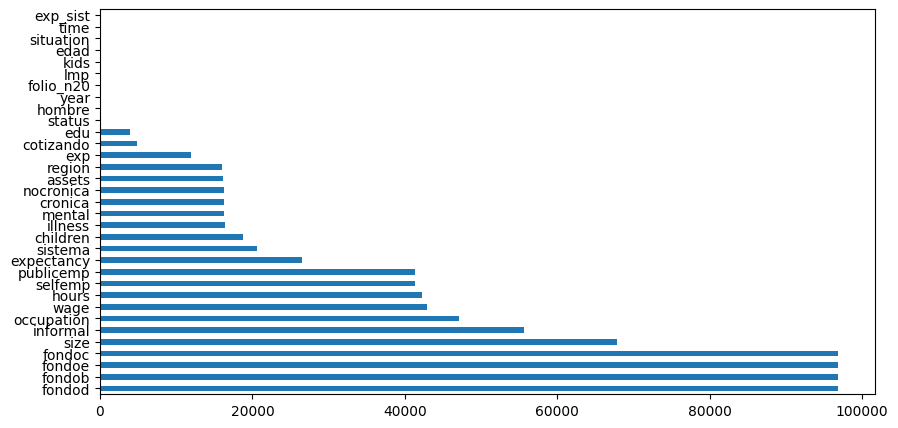

In [4]:
df.isna().sum().sort_values(ascending=False)[1:].plot(kind='barh', figsize=(10, 5))

In [5]:
for i in range(len(df.isna().sum().sort_values(ascending=False))):
    print(f"El porcentaje de nan de la columna{df.isna().sum().sort_values(ascending=False)[i]} es: ", (df.isna().sum().sort_values(ascending=False)[i])/96846*100)
    print("\n")

El porcentaje de nan de la columna96846 es:  100.0


El porcentaje de nan de la columna96846 es:  100.0


El porcentaje de nan de la columna96846 es:  100.0


El porcentaje de nan de la columna96846 es:  100.0


El porcentaje de nan de la columna96846 es:  100.0


El porcentaje de nan de la columna67802 es:  70.01011915825124


El porcentaje de nan de la columna55587 es:  57.39731119509324


El porcentaje de nan de la columna47069 es:  48.6019040538587


El porcentaje de nan de la columna42949 es:  44.34772731966214


El porcentaje de nan de la columna42270 es:  43.646614212254505


El porcentaje de nan de la columna41344 es:  42.69045701422878


El porcentaje de nan de la columna41344 es:  42.69045701422878


El porcentaje de nan de la columna26565 es:  27.43014683105136


El porcentaje de nan de la columna20643 es:  21.315284059228055


El porcentaje de nan de la columna18829 es:  19.442207215579373


El porcentaje de nan de la columna16438 es:  16.973339115709475


El porcentaje de 

# Eliminamos datos con exceso de Nans

In [6]:
# fondoa        96846
# fondod        96846
# fondob        96846
# fondoe        96846
# fondoc        96846
# size          67802
# informal      55587
# occupation    47069
# wage          42949
# hours         42270
# selfemp       41344
# publicemp     41344
# expectancy    26565

In [7]:
df=df.drop(columns=["fondoa", "fondod", "fondob", "fondoe", "fondoc","size","informal","occupation","wage","hours","selfemp","publicemp"], axis=1)

In [8]:
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,0.0,0.00,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,0.0,0.0,0.00,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,1.0,0.0,0.00,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,6.0,1.0,0.0,989038.06,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,1.0,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,1.0,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,1.0,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,1.0,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0


<Axes: >

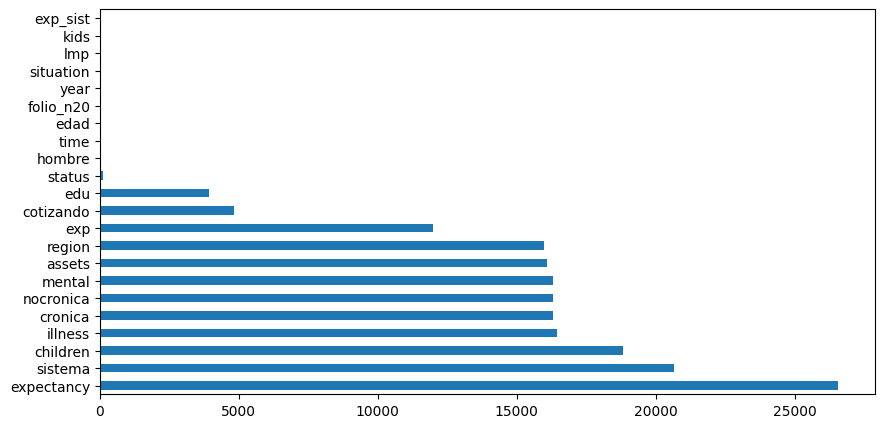

In [9]:
df.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5))

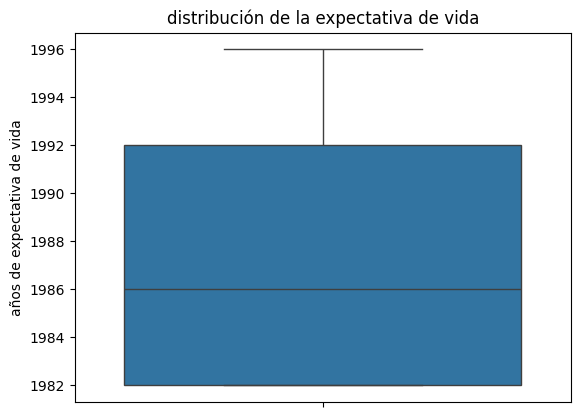

<Axes: ylabel='exp'>

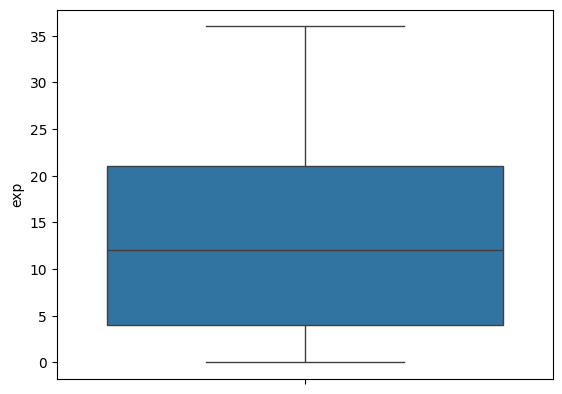

In [10]:
# vemos la distribucion de los datos
df.describe()
sns.boxplot(y=df["edad"], data=df, showfliers=False)
plt.title('distribución de la expectativa de vida')
plt.ylabel("años de expectativa de vida")
plt.show()

sns.boxplot(y=df["exp"], data=df, showfliers=True)

In [11]:
df["expectancy"].describe()

count    70281.000000
mean       131.131273
std        216.851544
min         25.000000
25%         70.000000
50%         80.000000
75%         85.000000
max        999.000000
Name: expectancy, dtype: float64

# inicio revision general

# Examinamos las columnas

# Hombre

In [12]:
print(df["hombre"].value_counts())
print("n\)")
df["hombre"].value_counts(normalize=True)
df["hombre"].unique()
print(df["hombre"].dtypes)

hombre
0.0    48884
1.0    47912
Name: count, dtype: int64
n\)
float64


In [13]:
df["hombre"].describe()

count    96796.000000
mean         0.494979
std          0.499977
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: hombre, dtype: float64

In [14]:
df_hombre=df[df["hombre"]==1]
df_hombre.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
count,4.791200e+04,47912.000000,47912.000000,47912.000000,47912.0,45926.000000,40587.000000,47860.000000,47912.000000,37891.000000,...,42555.000000,41067.000000,46304.000000,4.055100e+04,47912.000000,35568.000000,38914.000000,38979.000000,38979.000000,38979.000000
mean,1.253048e+11,7.769014,3.407309,1753.878778,1.0,7.821365,9.078942,2.458420,0.360494,0.770605,...,16.228105,0.873913,0.492268,6.160704e+06,15.505030,128.959852,0.282932,0.171066,0.063239,0.035506
std,1.288049e+09,4.571644,1.736416,628.842335,0.0,5.085170,3.656387,1.739342,0.480149,1.025900,...,9.053660,0.331951,0.499946,1.193174e+07,10.319523,211.491754,0.450429,0.376572,0.243396,0.185058
min,1.245602e+11,2.000000,1.000000,20.000000,1.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246184e+11,4.000000,2.000000,1982.000000,1.0,3.000000,6.000000,1.000000,0.000000,0.000000,...,9.000000,1.000000,0.000000,1.715265e+05,6.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247055e+11,6.000000,3.000000,1986.000000,1.0,7.000000,9.000000,1.000000,0.000000,0.000000,...,18.000000,1.000000,0.000000,2.071205e+06,17.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248357e+11,12.000000,5.000000,1992.000000,1.0,12.000000,13.000000,5.000000,1.000000,1.000000,...,23.000000,1.000000,1.000000,6.855588e+06,24.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.0,19.000000,15.000000,5.000000,1.000000,8.000000,...,36.000000,1.000000,1.000000,2.462820e+08,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df_mujer=df[df["hombre"]==0]
df_mujer.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
count,4.888400e+04,48884.000000,48884.000000,48884.000000,48884.0,46947.000000,40221.000000,48826.000000,48884.000000,40084.000000,...,42264.000000,35127.000000,45689.000000,4.016800e+04,48884.000000,34687.000000,41445.000000,41509.00000,41509.000000,41509.000000
mean,1.253282e+11,8.208616,3.578594,1596.166558,0.0,7.990841,9.219413,2.785934,0.353633,0.714175,...,9.255016,0.860478,0.328044,1.291547e+06,11.496011,133.343616,0.434311,0.25262,0.082319,0.110747
std,1.302965e+09,4.550868,1.714267,775.592242,0.0,5.125748,3.698208,1.711313,0.478102,1.001387,...,8.752591,0.346496,0.469506,4.237354e+06,9.994080,222.171657,0.495672,0.43452,0.274854,0.313822
min,1.245602e+11,2.000000,1.000000,20.000000,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,26.000000,0.000000,0.00000,0.000000,0.000000
25%,1.246240e+11,4.000000,2.000000,1982.000000,0.0,3.000000,6.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000e+00,0.000000,70.000000,0.000000,0.00000,0.000000,0.000000
50%,1.247840e+11,9.000000,4.000000,1986.000000,0.0,8.000000,9.000000,2.000000,0.000000,0.000000,...,7.000000,1.000000,0.000000,0.000000e+00,11.000000,80.000000,0.000000,0.00000,0.000000,0.000000
75%,1.248377e+11,12.000000,5.000000,1992.000000,0.0,12.000000,13.000000,5.000000,1.000000,1.000000,...,16.000000,1.000000,1.000000,6.876333e+05,20.000000,85.000000,1.000000,1.00000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,0.0,19.000000,15.000000,5.000000,1.000000,8.000000,...,35.000000,1.000000,1.000000,1.321654e+08,35.000000,999.000000,1.000000,1.00000,1.000000,1.000000


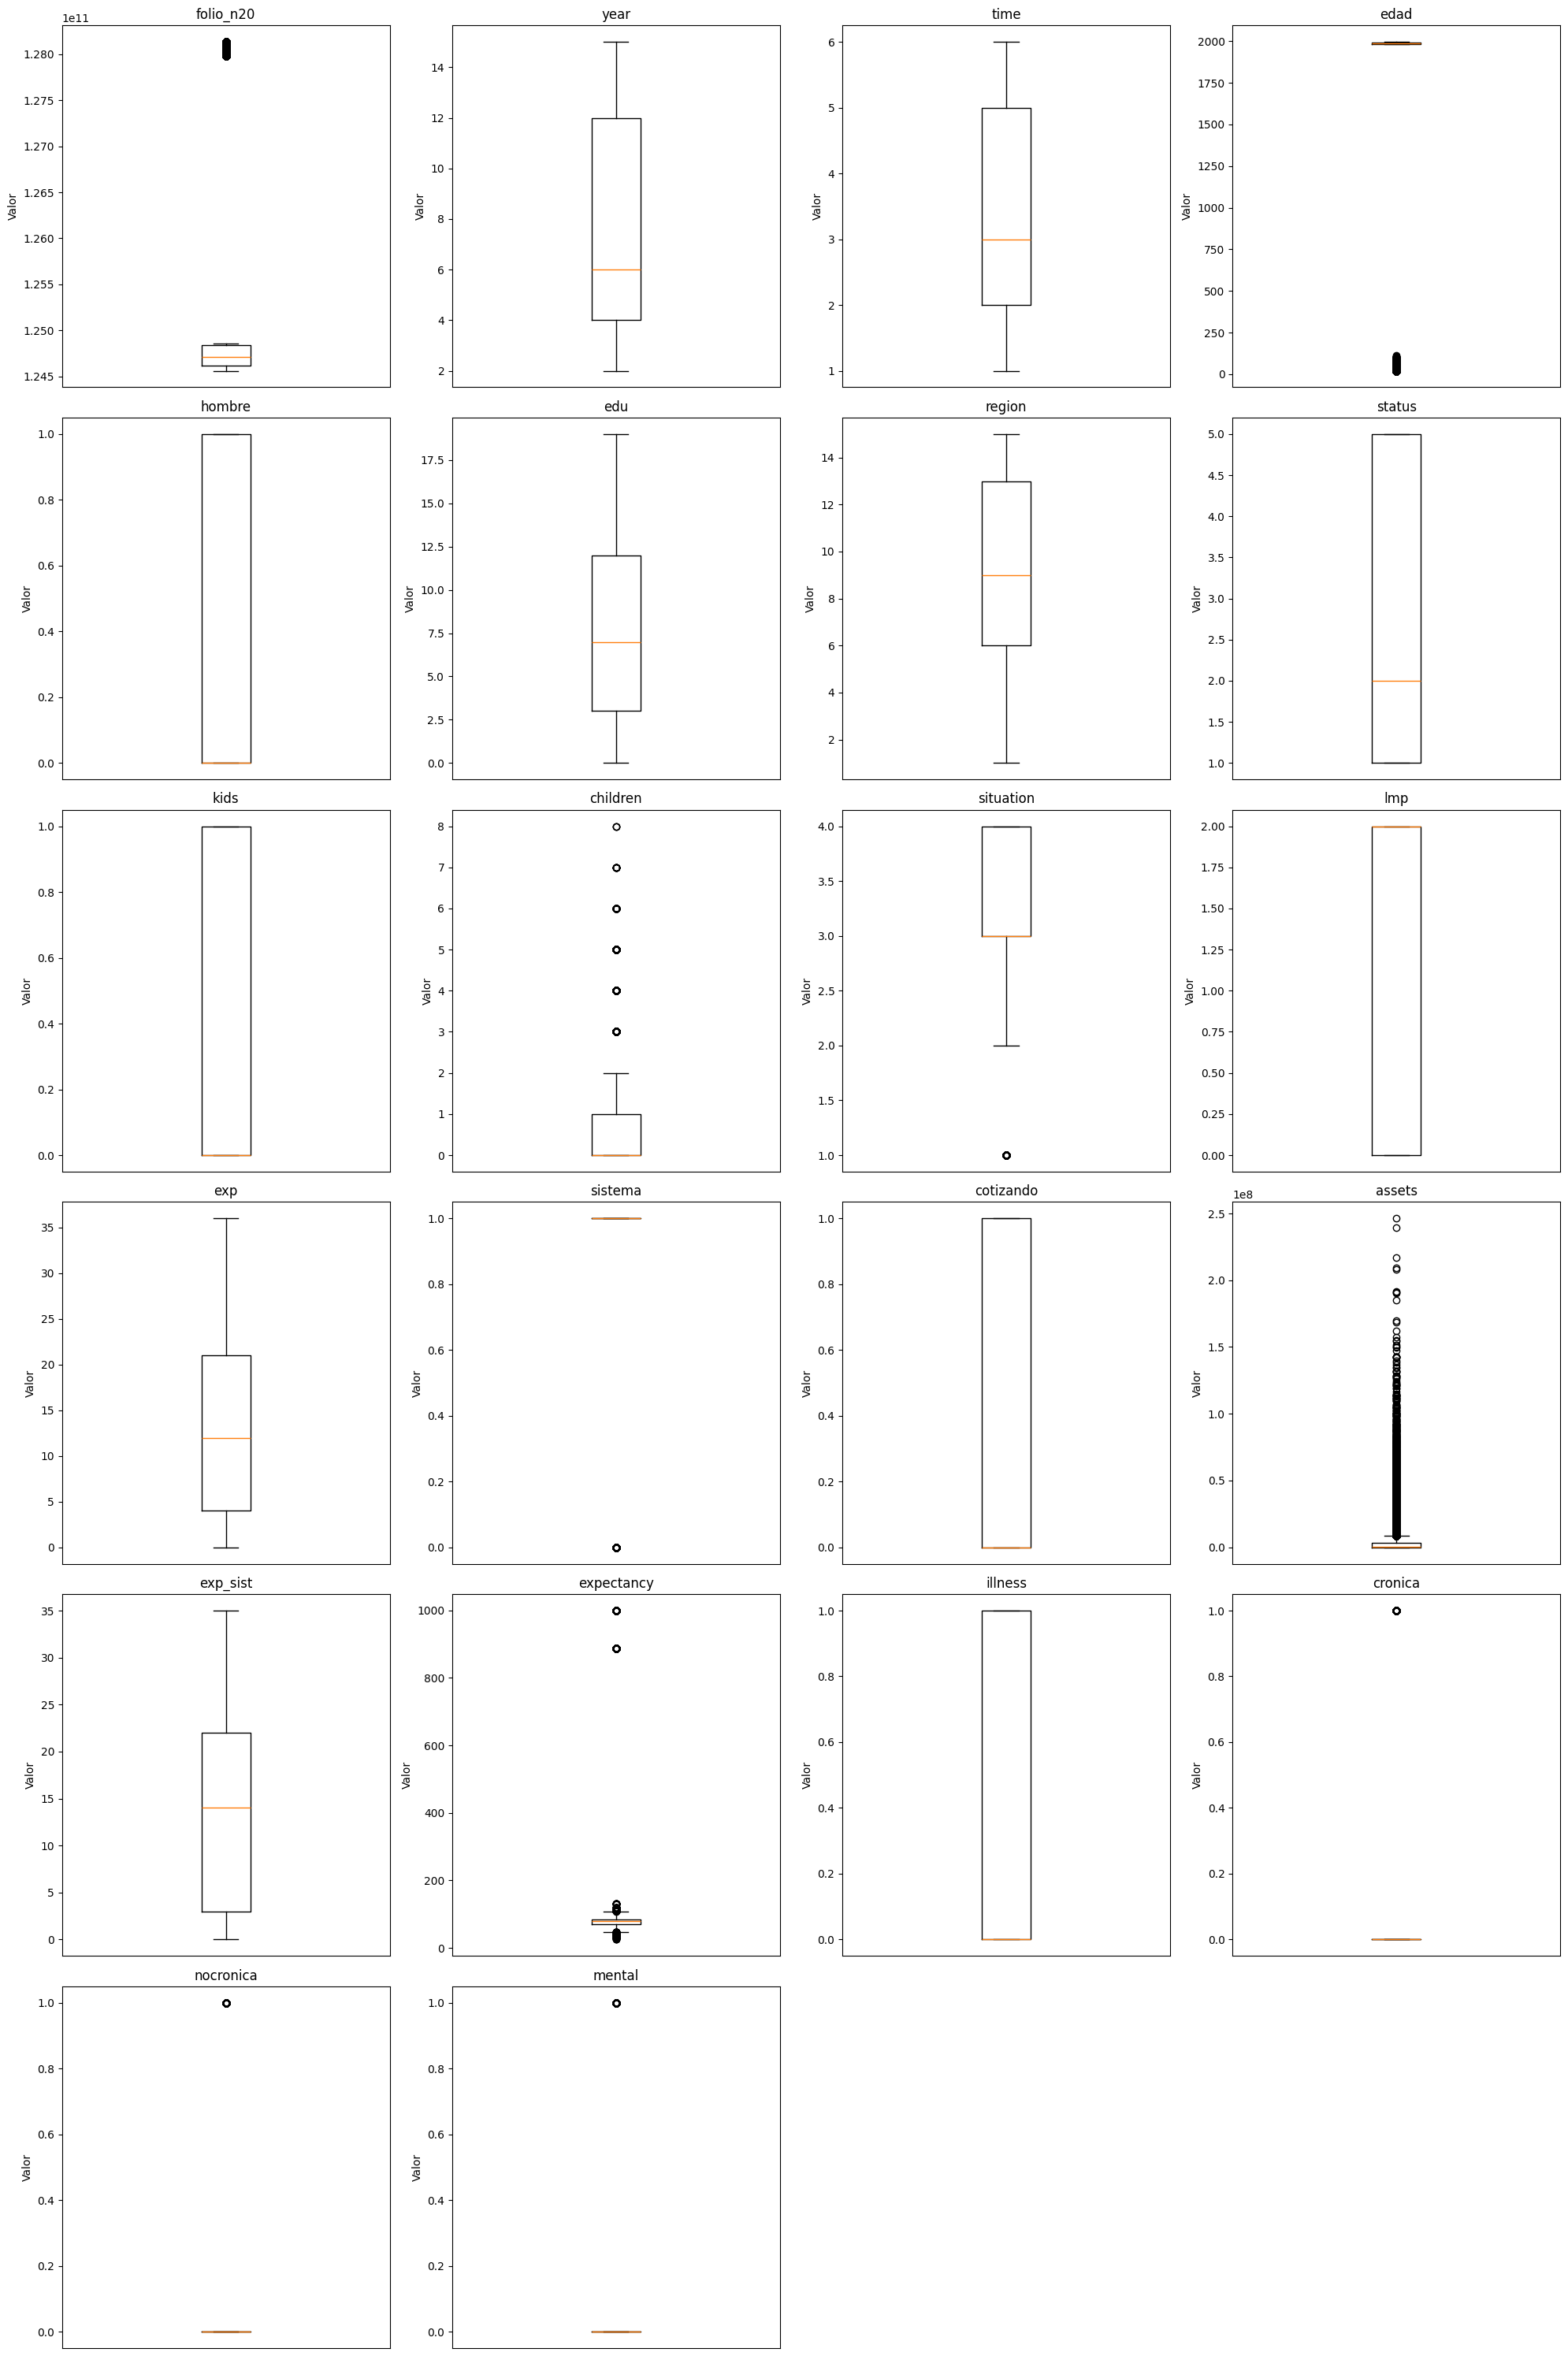

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Filtramos solo columnas numéricas
numeric_cols = df.select_dtypes(include='number').columns
num_vars = len(numeric_cols)

# Configuración de 4 por fila
plots_per_row = 4
n_rows = math.ceil(num_vars / plots_per_row)

# figura
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(5 * plots_per_row, 5 * n_rows))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')
    axes[i].set_xticks([])

# Ocultar los ejes sobrantes si hay menos de plots_per_row * n_rows
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [17]:
df_panel = df.sort_values(["folio_n20", "time"], ascending=[True, True])
df_panel.head(20)

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,0.0,0.000,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,0.0,0.0,0.000,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,1.0,0.0,0.000,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,6.0,1.0,0.0,989038.060,19,75.0,NaN,NaN,NaN,NaN
5,124560205935,4,2,1984,0.0,15.0,13.0,3.0,1,3.0,...,6.0,1.0,0.0,0.000,21,70.0,1.0,1.0,1.0,0.0
6,124560210408,2,1,1982,0.0,4.0,13.0,1.0,1,1.0,...,22.0,1.0,1.0,89575.539,4,70.0,NaN,NaN,NaN,NaN
7,124560210408,4,2,1984,0.0,4.0,13.0,1.0,0,0.0,...,23.0,1.0,1.0,0.000,6,70.0,0.0,0.0,0.0,0.0
8,124560210408,6,3,1986,0.0,3.0,13.0,1.0,0,0.0,...,26.0,1.0,1.0,154486.300,8,75.0,1.0,1.0,0.0,0.0
9,124560210408,9,4,1989,0.0,3.0,13.0,3.0,0,0.0,...,29.0,1.0,1.0,0.000,11,999.0,1.0,1.0,0.0,1.0


[  49   51   54   57 1982 1984 1986 1989 1992 1995   50   52   55   58
   61   48 1983 1985 1987 1996   53 1990 1993   56   59   62   65   63
   46   64   60   67   70   81   83   85   74   76   78   84   87   82
   79   72   80   69   71   73   90   93   75   77   68   66   92   94
   96   88   86   95   45   47   42   44   43   91   89   98  100  111
   34   36   39   97   99  103   37   27   31  101  105  108   29   38
   40   41   35   33   22   20   21   26   28   25   24   23   30   32]


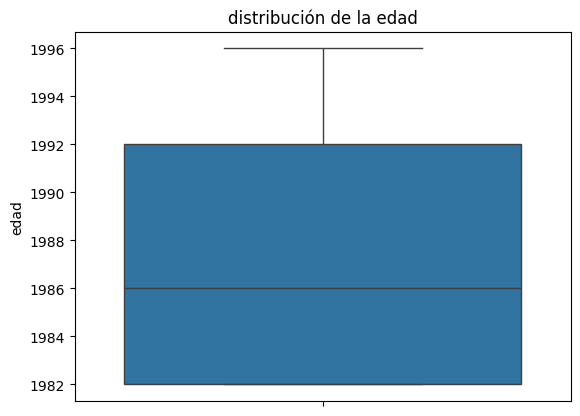

In [18]:
sns.boxplot(y=df["edad"], data=df_panel, showfliers=False)
plt.title('distribución de la edad')
#df_panel["edad"].describe()
print(df_panel["edad"].unique())

datos sobre la edad escrita bien: 
 
 count    15841.000000
mean        63.639606
std         16.374911
min         20.000000
25%         55.000000
50%         66.000000
75%         75.000000
max        111.000000
Name: edad, dtype: float64 
 -------------------------
 
 hay 5800 registros de personas con 20 años


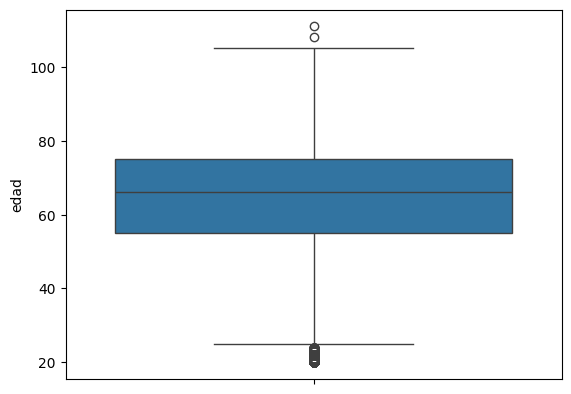

In [19]:
df_panel["edad"].astype(int)
df_panel["edad"].dtypes
sns.boxplot(y=df_panel[df_panel["edad"] <= 120]["edad"], data=df_panel, showfliers=True)
print("datos sobre la edad escrita bien: \n \n", df_panel[df_panel["edad"] <= 120]["edad"].describe(),"\n -------------------------\n \n", f"hay {df_panel[df_panel["edad"] == 20]["edad"].sum()} registros de personas con 20 años")

# Fin revision general

# agrupamos por folio y time para datos de panel

# necesario para correr los modelos

In [20]:
df_index_panel = df.set_index(['folio_n20', 'time']).sort_index(ascending=[False, True]) 


<Axes: >

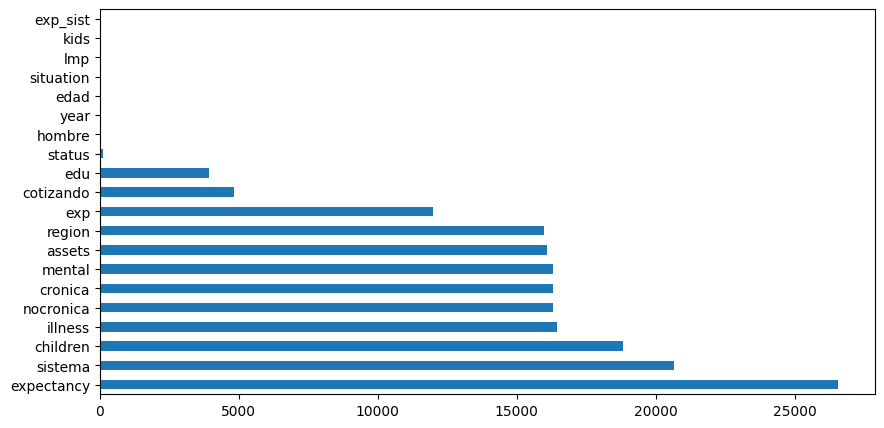

In [21]:
df_index_panel.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5)) 

In [22]:
df_index_panel["year"].unique()


array([12, 15,  4,  6,  9,  2])

In [23]:
print(df_index_panel["expectancy"].unique())
df_copia=df_index_panel.copy()

[ 90.  70.  75.  80.  60.  87.  95. 100.  65.  85.  66.  40.  86.  69.
  50.  68.  76.  78.  99. 130.  nan  89.  82.  55.  88.  84.  64.  97.
  54.  71.  67.  94.  79. 999. 888.  45.  73.  62.  72.  92.  81. 105.
  98.  63.  28.  56.  96.  74.  58.  77. 104.  30. 120.  83. 102.  44.
 111.  35. 129.  91.  38. 110.  37.  26.  51.  48.  52.  59. 101.  93.
  34.  42.  25. 103.  53.  47.  61.  33.  57.  46.  39.  49.  43.  41.
  36. 115. 107. 106.  32. 109. 108.]


In [24]:
df_index_panel=df_index_panel.dropna(subset=["expectancy"])

<Axes: >

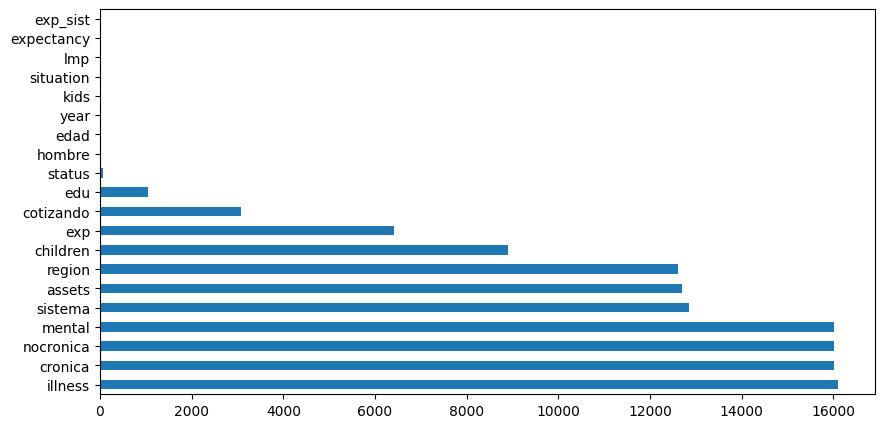

In [25]:
df_index_panel.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5)) 

In [26]:
a=2025-1982
a

43

In [27]:
df_index_panel["expectancy"].unique()

array([ 90.,  70.,  75.,  80.,  60.,  87.,  95., 100.,  65.,  85.,  66.,
        40.,  86.,  69.,  50.,  68.,  76.,  78.,  99., 130.,  89.,  82.,
        55.,  88.,  84.,  64.,  97.,  54.,  71.,  67.,  94.,  79., 999.,
       888.,  45.,  73.,  62.,  72.,  92.,  81., 105.,  98.,  63.,  28.,
        56.,  96.,  74.,  58.,  77., 104.,  30., 120.,  83., 102.,  44.,
       111.,  35., 129.,  91.,  38., 110.,  37.,  26.,  51.,  48.,  52.,
        59., 101.,  93.,  34.,  42.,  25., 103.,  53.,  47.,  61.,  33.,
        57.,  46.,  39.,  49.,  43.,  41.,  36., 115., 107., 106.,  32.,
       109., 108.])

In [28]:
df_index_panel.columns

Index(['year', 'edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental'],
      dtype='object')

In [29]:
#df_index_panel[df_index_panel["exp"]==0 ].head(20)

<Axes: xlabel='region', ylabel='expectancy'>

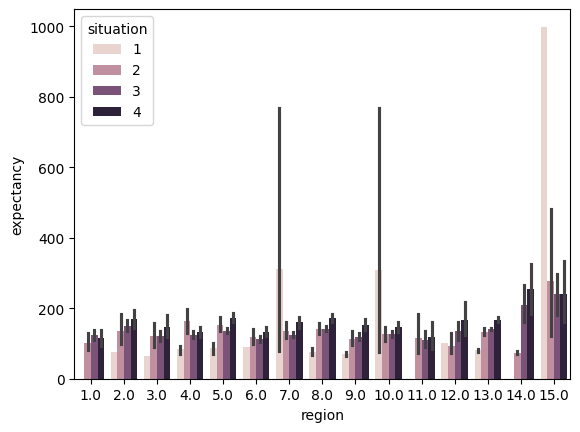

In [30]:
df_index_panel.groupby(["region", "situation"]).agg({"expectancy": ["mean", "std"]}).reset_index()
sns.barplot(x="region", y="expectancy", hue="situation", data=df_index_panel)

Resumen hasta ahora, exp se queda y se fueron 27k datos, pero es clave

de las columnas que quedan...hombre puede ser util
edu se deja, falta revisar
el tiempo cotizando no me parece influyente, pero probemos
el status quizas afecta para viudo, de un periodo a otro
situation debe ser clave
enfermedades cronica no cronica y mental, interesantes

podriamos armar un modelo full economico y otro por salud

In [31]:
df_index_panel.columns

Index(['year', 'edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental'],
      dtype='object')

In [32]:
df.isna().sum().sort_values(ascending=False)


expectancy    26565
sistema       20643
children      18829
illness       16438
cronica       16309
nocronica     16309
mental        16309
assets        16087
region        15998
exp           11977
cotizando      4808
edu            3926
status          110
hombre           50
time              0
edad              0
folio_n20         0
year              0
situation         0
lmp               0
kids              0
exp_sist          0
dtype: int64

In [33]:
df_index_panel["sistema"].value_counts(dropna=False)

sistema
1.0    50283
NaN    12842
0.0     7156
Name: count, dtype: int64

In [34]:
df_index_panel.columns

Index(['year', 'edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental'],
      dtype='object')

In [35]:
print(df_index_panel.year.unique())
print(df_index_panel["edu"].mean())    

[12  4  6  9  2]
8.070194696400716


In [36]:
df_index_panel.dtypes

year            int64
edad            int64
hombre        float64
edu           float64
region        float64
status        float64
kids            int64
children      float64
situation       int64
lmp             int64
exp           float64
sistema       float64
cotizando     float64
assets        float64
exp_sist        int64
expectancy    float64
illness       float64
cronica       float64
nocronica     float64
mental        float64
dtype: object

In [37]:
for i in range(len(df_index_panel.columns)):
    print(f"El tipo de dato de la columna {df_index_panel.columns[i]} es: ", df_index_panel[df_index_panel.columns[i]].dtypes)
    print("\n")
    print(f"El tipo de dato de la columna {df_index_panel.columns[i]} es: ", df_index_panel[df_index_panel.columns[i]].unique())
    print("\n")

El tipo de dato de la columna year es:  int64


El tipo de dato de la columna year es:  [12  4  6  9  2]


El tipo de dato de la columna edad es:  int64


El tipo de dato de la columna edad es:  [1992   25   38   41   36   29   27   28   31   33   32   51   35   43
   42   50   49   45   34   44   39   40   30   24   23   47   52   55
   60   63 1987   65   68   62   64   21   26   66   70 1985 1990   78
   81   73   54   56   59   48   77   82   72   46   75   58   71   69
 1984 1986 1989   20 1982   74   83   86   67   61   88   90   53   22
   85   37   76   57   84   87   79   91   93   96 1993 1983   80   92
   94   98  100   89   95  101   97   99  103  105  108]


El tipo de dato de la columna hombre es:  float64


El tipo de dato de la columna hombre es:  [ 1.  0. nan]


El tipo de dato de la columna edu es:  float64


El tipo de dato de la columna edu es:  [ 8. 15. 12. 16. 18. 13. 11. 17.  7. 14.  4. 10.  3. nan  9.  2. 19.  1.
  0.  5.  6.]


El tipo de dato de la columna reg

<Axes: xlabel='hombre', ylabel='sistema'>

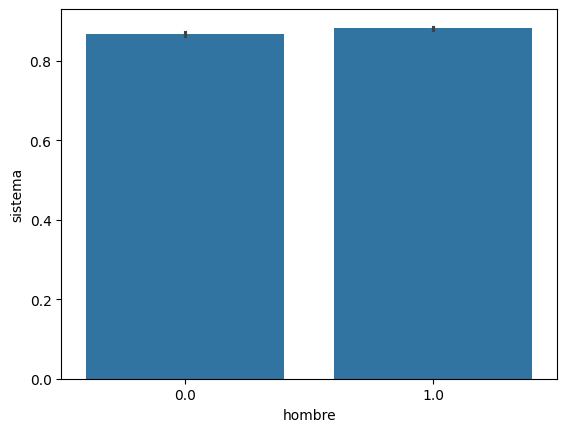

In [38]:

sns.barplot(data=df_index_panel, x="hombre", y="sistema")

# que variables podriamos usar?

vas a usar:


 - wage(si no se borro por nans, aplica para el resto)(no)
 - hours(no)
 - selfemp(no)
-------------------------
SI
 - hombre 
 -  region
 - kids
 - children
 - cotizando
 - assets
 - edu
 - exp
 - illnes /cronica /no cronica /mental

In [39]:
print(df_index_panel.isna().sum(), "\n", "hombre, region, kids and children, cotizando, assets, edu, exp, illnes, cronica, no cronica, mentales")


year              0
edad              0
hombre           26
edu            1045
region        12610
status           59
kids              0
children       8891
situation         0
lmp               0
exp            6404
sistema       12842
cotizando      3078
assets        12697
exp_sist          0
expectancy        0
illness       16102
cronica       16012
nocronica     16012
mental        16012
dtype: int64 
 hombre, region, kids and children, cotizando, assets, edu, exp, illnes, cronica, no cronica, mentales


# inicio limpieza nan y demas cosas para variables nominadas

 1) vas a usar hombre:
- elimina nans
-------------
2) vas a usar region:
- dummies


--------------
3) vas a usar children: 
- elimina nans
- verifica que tengan sentido con los datos de kids(dummies)
4) vas a usar kids: (lo anterior)

----------------
5) vas a usar assets:
- eliminar nans

----------------
6) vas a usar edu(variable de interes):
- eliminar nans
- dummies
----------------
7) vas a usar expectancy(variable de interes):
- eliminar nans

----------------
8) illnes cronica no cronica y mentales tienen el mismo numero de nans debe haber un patron:
- dummies



__1)__

In [40]:
df_index_panel=df_index_panel.dropna(subset=["hombre"])


In [41]:
df_index_panel.isna().sum().sort_values(ascending=False)

illness       16101
cronica       16011
nocronica     16011
mental        16011
sistema       12818
assets        12697
region        12610
children       8887
exp            6404
cotizando      3078
edu            1044
status           59
hombre            0
edad              0
year              0
kids              0
situation         0
lmp               0
expectancy        0
exp_sist          0
dtype: int64

__2)__

__3)__

In [42]:
datita= df_index_panel.groupby(["kids", "children"]).mean().reset_index()
datita

,kids,children,year,edad,hombre,edu,region,status,situation,lmp,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,0,0.0,7.181815,1530.848832,0.493018,7.357260,9.240412,2.754167,3.344476,0.968055,12.978478,0.773772,0.351422,3.555851e+06,11.949055,140.414823,0.414222,0.287912,0.087468,0.070088
1,1,1.0,5.817726,1858.259035,0.485558,8.567925,9.119507,2.127376,3.072540,1.403653,13.451744,0.957995,0.525428,3.840316e+06,15.530599,124.498549,0.274978,0.160102,0.055634,0.074532
2,1,2.0,5.205771,1904.971036,0.525883,8.756262,9.158613,1.654013,3.078461,1.386469,13.324408,0.976408,0.529070,4.161121e+06,15.993732,115.194640,0.231845,0.133238,0.042084,0.067492
3,1,3.0,4.970977,1908.057759,0.517241,8.460492,8.826745,1.638689,3.101724,1.344540,12.785124,0.972885,0.492451,3.576976e+06,15.883908,109.883908,0.223597,0.128035,0.041060,0.074614
4,1,4.0,4.972121,1916.830303,0.517576,8.106618,9.145098,1.647273,3.104242,1.269091,12.740695,0.984932,0.455215,3.188005e+06,16.167273,104.086061,0.233591,0.111753,0.067437,0.077071
5,1,5.0,4.787736,1810.580189,0.462264,7.033333,7.791045,1.608491,3.132075,1.146226,11.975490,0.971910,0.385714,2.009763e+06,14.801887,99.391509,0.246269,0.119403,0.052239,0.074627
6,1,6.0,5.377358,1911.981132,0.528302,6.115385,8.163265,1.735849,3.150943,1.283019,12.540000,0.974359,0.313725,1.644462e+06,14.150943,91.301887,0.179487,0.102564,0.025641,0.025641
7,1,7.0,6.100000,1791.000000,0.300000,5.600000,8.750000,2.300000,3.300000,0.900000,9.700000,1.000000,0.200000,7.719312e+05,12.400000,154.000000,0.375000,0.375000,0.000000,0.125000
8,1,8.0,3.333333,1335.333333,0.666667,3.666667,9.000000,1.666667,3.333333,1.333333,10.666667,0.666667,0.333333,2.742924e+05,11.000000,75.000000,0.000000,0.000000,0.000000,0.000000


In [43]:
# Personas que dicen que no tienen hijos pero tienen cantidad > 0
inconsistentes_1 = df_index_panel[(df_index_panel["kids"] == False) & (df_index_panel["children"] > 0)]

# Personas que dicen tener hijos pero cantidad = 0
inconsistentes_2 = df_index_panel[(df_index_panel["kids"] == True) & (df_index_panel["children"] == 0)]
#print(inconsistentes_2, inconsistentes_1)

if len(inconsistentes_1.kids) > 0:

    print("Personas que dicen no tener hijos pero tienen cantidad > 0:", inconsistentes_1)
else:
    print("esta vacio, todo bien, no hay inconsistencias con personas que dicen no tener hijos pero tienen cantidad > 0")

if len(inconsistentes_2.kids) > 0:
    print("Personas que dicen tener hijos pero cantidad = 0:", inconsistentes_2)
else:
    print("esta vacio, todo bien, no hay inconsistencias con personas que dicen tener hijos pero cantidad = 0")


#luego vemos los nans de kids y children
print(df_index_panel.kids.isna().sum(),
df_index_panel.children.isna().sum())

#veremos donde estan los nans children(kids no tiene nans)   
df_nan_children = df_index_panel[df_index_panel["children"].isna()]
todos_sin_hijos = (df_nan_children["kids"] == 0).all()

if todos_sin_hijos:
    print("Todos los que dicen no tener hijos y tienen NaN en 'children', en efecto tienen 0 hijos. Puedes reemplazar los NaN por 0 en ese caso.")

# Reemplazar NaN en children por 0
df_index_panel.loc[df_index_panel["children"].isna(), "children"] = 0
# Verificar que no haya más NaN en children
df_index_panel["children"].isna().sum()

# verificar nans en todas las columnas
df_index_panel.isna().sum().sort_values(ascending=False)


esta vacio, todo bien, no hay inconsistencias con personas que dicen no tener hijos pero tienen cantidad > 0
esta vacio, todo bien, no hay inconsistencias con personas que dicen tener hijos pero cantidad = 0
0 8887
Todos los que dicen no tener hijos y tienen NaN en 'children', en efecto tienen 0 hijos. Puedes reemplazar los NaN por 0 en ese caso.


illness       16101
cronica       16011
nocronica     16011
mental        16011
sistema       12818
assets        12697
region        12610
exp            6404
cotizando      3078
edu            1044
status           59
year              0
hombre            0
edad              0
kids              0
children          0
situation         0
lmp               0
expectancy        0
exp_sist          0
dtype: int64

__4)__  esta listo(anterior)

__5)__ no

__6)__

__7)__

valor maximo:  expectancy
False    63503
True      6752
Name: count, dtype: int64
valor minimo:  25.0


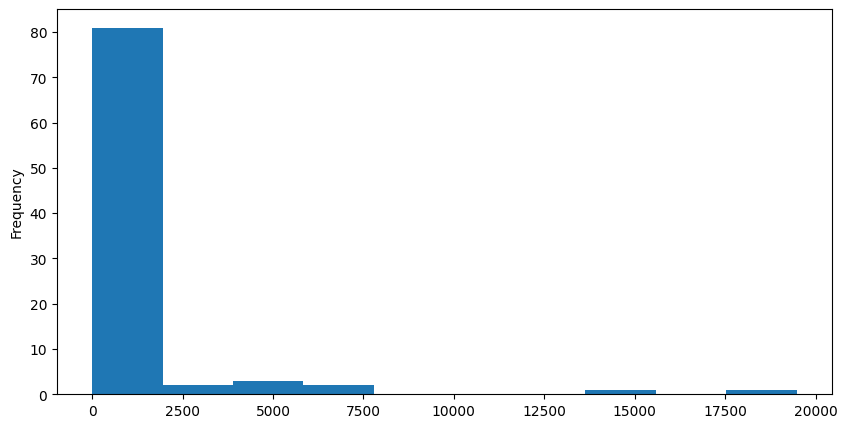

In [44]:
df_index_panel["expectancy"].value_counts(dropna=False).plot(kind="hist", figsize=(10, 5))  
print("valor maximo: ",(df_index_panel["expectancy"]>=100).value_counts())
print("valor minimo: ",min(df_index_panel["expectancy"]))

<Axes: ylabel='expectancy'>

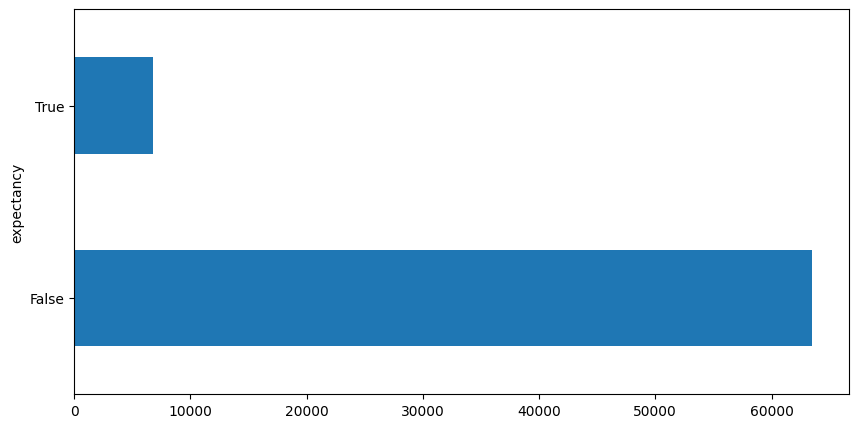

In [45]:
(df_index_panel["expectancy"]>=100).value_counts().plot(kind="barh", figsize=(10, 5))

In [46]:
print(df_index_panel["expectancy"].isna().sum(), "numero de nans: ", df_index_panel["expectancy"].isna().sum()/len(df_index_panel)*100, "%")

0 numero de nans:  0.0 %


expectancy
False    70255
Name: count, dtype: int64 numero de nans:  0


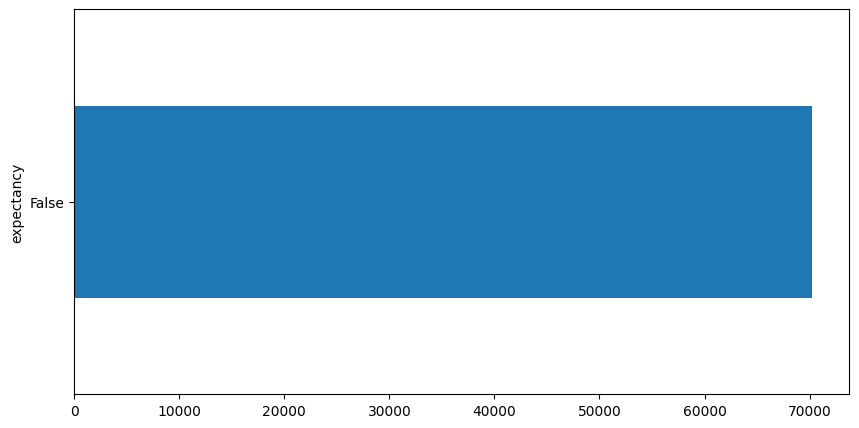

In [47]:
#data=df_index_panel.groupby("region").agg({"expectancy": ["mean"]}).reset_index()

df_index_panel["expectancy"]=df_index_panel["expectancy"].map(lambda x: 100 if x>=100 else x)

(df_index_panel["expectancy"]>100).value_counts().plot(kind="barh", figsize=(10, 5))
print((df_index_panel["expectancy"]>100).value_counts(), "numero de nans: ", df_index_panel["expectancy"].isna().sum())

In [48]:
df_index_panel.shape
df_index_panel.columns

Index(['year', 'edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental'],
      dtype='object')

__8)__

In [49]:
nan_exactos_x_fila = df_index_panel["illness"].isna()

a = (df_index_panel["cronica"].isna() == nan_exactos_x_fila).all()
b = (df_index_panel["nocronica"].isna() == nan_exactos_x_fila).all()
c = (df_index_panel["mental"].isna() == nan_exactos_x_fila).all()

if a and b and c:
    print(" Todas las columnas de enfermedad tienen el mismo NaN en las filas exactas")
    print("cronica tiene los mismos NaN que illness")
    print("nocronica tiene los mismos NaN que illness")
    print("mental tiene los mismos NaN que illness")
elif a and b:
    print("cronica tiene los mismos NaN que illness")
    print("nocronica tiene los mismos NaN que illness")
    print("mental no tiene los mismos NaN que illness")
elif a and c:
    print("cronica tiene los mismos NaN que illness")
    print("mental tiene los mismos NaN que illness")
    print("nocronica no tiene los mismos NaN que illness")
elif b and c:
    print("nocronica tiene los mismos NaN que illness")
    print("mental tiene los mismos NaN que illness")
    print("cronica no tiene los mismos NaN que illness")
else:
    if not a:
        print("cronica no tiene los mismos NaN que illness") 
    if not b:
        print("nocronica no tiene los mismos NaN que illness")
    if not c:
        print("mental no tiene los mismos NaN que illness")


cronica no tiene los mismos NaN que illness
nocronica no tiene los mismos NaN que illness
mental no tiene los mismos NaN que illness


In [50]:
# Filtrar filas donde illness es NaN
filtro_nan_illness = df_index_panel["illness"].isna()

# Filtrar esas filas
df_nan_illness = df_index_panel[filtro_nan_illness]

# Ver si en esas mismas filas las otras 3 columnas también son NaN
coincidencia_total = df_nan_illness[["cronica", "nocronica", "mental"]].isna().all(axis=1)

# Mostrar las filas donde todas las columnas son NaN
df_completamente_nan = df_nan_illness[coincidencia_total]

# También puedes contar cuántas filas cumplen esto:
print(f"{df_completamente_nan.shape[0]} filas tienen NaN en illness, cronica, nocronica y mental al mismo tiempo.")
coincidencia_total.value_counts()





##########################
###### PENDIENTE ##########
##########################

#ya se reviso, se soluciono lo de las 90(tambien se reviso lo de los 16k)(esto mas adelante)

16011 filas tienen NaN en illness, cronica, nocronica y mental al mismo tiempo.


True     16011
False       90
Name: count, dtype: int64

In [51]:
# Filtro donde las 4 columnas son NaN a la vez
filtro_todas_nan = df_index_panel[["illness", "cronica", "nocronica", "mental"]].isna().all(axis=1)

# Guardamos esas filas
df_nan_completo = df_index_panel[filtro_todas_nan]

print(f"Filas con NaN en illness, cronica, nocronica y mental: {df_nan_completo.shape[0]}")


Filas con NaN en illness, cronica, nocronica y mental: 16011


In [52]:
# illness es NaN, pero no todas las demás lo son
filtro_illness_nan = df_index_panel["illness"].isna()
filtro_otros_no_nan = ~df_index_panel[["cronica", "nocronica", "mental"]].isna().all(axis=1)

# Filas con inconsistencias
df_inconsistentes = df_index_panel[filtro_illness_nan & filtro_otros_no_nan]

print(f"Filas donde illness es NaN, pero al menos una de las otras NO lo es: {df_inconsistentes.shape[0]}")


Filas donde illness es NaN, pero al menos una de las otras NO lo es: 90


In [53]:
# Filtro: illness es NaN y alguna enfermedad específica es 1
filtro = df_index_panel["illness"].isna() & (
    (df_index_panel["cronica"] == 1) |
    (df_index_panel["nocronica"] == 1) |
    (df_index_panel["mental"] == 1)
)

# Contar cuántas correcciones se harán
n_correcciones = filtro.sum()

# Aplicar corrección
df_index_panel.loc[filtro, "illness"] = 1

# Mostrar resultado
print(f"Se corrigieron {n_correcciones} filas: illness fue imputado como 1 porque al menos una enfermedad estaba presente.")


Se corrigieron 0 filas: illness fue imputado como 1 porque al menos una enfermedad estaba presente.


In [54]:
# Filtro: illness es NaN y las 3 enfermedades también son NaN
filtro_todo_nan = (
    df_index_panel["illness"].isna() &
    df_index_panel["cronica"].isna() &
    df_index_panel["nocronica"].isna() &
    df_index_panel["mental"].isna()
)

#Contar cuántas filas cumplen esto
n_casos_para_cero = filtro_todo_nan.sum()
print(f"{n_casos_para_cero} filas tienen illness y todas las enfermedades como NaN.")

# imputar illness = 0 en esos casos
df_index_panel.loc[filtro_todo_nan, "illness"] = 0
print(f"Se imputó illness = 0 en esas filas.")


16011 filas tienen illness y todas las enfermedades como NaN.
Se imputó illness = 0 en esas filas.


<Axes: >

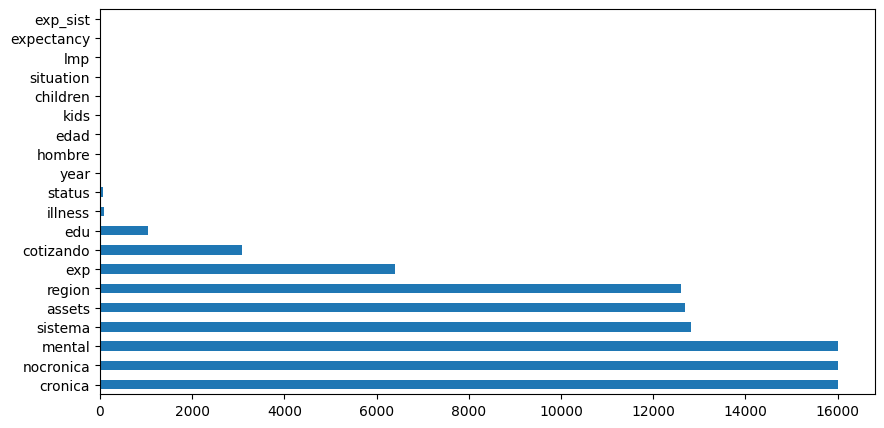

In [55]:
df_index_panel.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5))

In [56]:
# Filtrar filas donde illness es NaN
illness_nan = df_index_panel[df_index_panel["illness"].isna()]

# Ver cuántas son
print(f"Filas con illness NaN: {len(illness_nan)}")

#Mostrar primeras filas
print(illness_nan.head(90))

#PUEDE SER UN ERROR DE IMPUTACION


Filas con illness NaN: 90
                   year  edad  hombre   edu  region  status  kids  children  \
folio_n20    time                                                             
128128004073 5       12  1992     0.0   7.0     NaN     5.0     0       0.0   
128127182745 5       12  1992     1.0   8.0     NaN     5.0     0       0.0   
128126756532 5       12  1992     0.0  16.0     NaN     5.0     0       0.0   
128123184309 5       12  1992     0.0  12.0     NaN     5.0     0       0.0   
128122507537 5       12  1992     1.0  14.0     NaN     5.0     0       0.0   
...                 ...   ...     ...   ...     ...     ...   ...       ...   
124575548112 5       12  1992     1.0   1.0     NaN     1.0     0       0.0   
124570435473 5       12  1992     1.0   NaN     NaN     NaN     0       0.0   
124569595969 2        4    61     0.0   0.0     7.0     1.0     0       0.0   
124565089315 5       12  1992     1.0   7.0     NaN     1.0     0       0.0   
124560739784 5       12   

In [57]:
# Filtrar filas donde illness es NaN y las otras 3 columnas son 0
filtro_nan_y_0 = (
    df_index_panel["illness"].isna() &
    (df_index_panel["cronica"] == 0) &
    (df_index_panel["nocronica"] == 0) &
    (df_index_panel["mental"] == 0)
)

# Contar cuántas filas cumplen esto
n_filas = filtro_nan_y_0.sum()
print(f"Hay {n_filas} filas donde illness es NaN pero las otras 3 enfermedades son 0.")

# Imputar illness = 0 en esas filas
df_index_panel.loc[filtro_nan_y_0, "illness"] = 0
print("Se imputó illness = 0 en esas filas.")


Hay 90 filas donde illness es NaN pero las otras 3 enfermedades son 0.
Se imputó illness = 0 en esas filas.


(70255, 20)

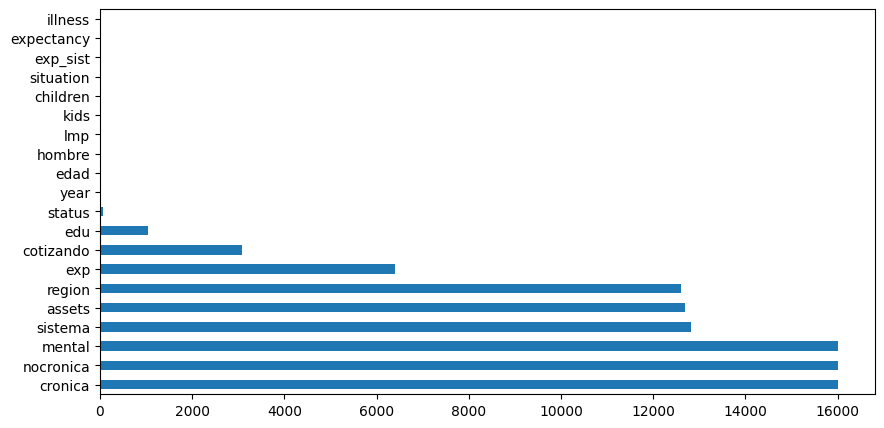

In [58]:
df_index_panel.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5))
df_index_panel.shape

In [59]:
# Filtrar filas donde illness es 0
filtro_illness_0 = df_index_panel["illness"] == 0

# Para esas filas, reemplazar NaN o cualquier valor en las otras 3 columnas por 0
df_index_panel.loc[filtro_illness_0, ["cronica", "nocronica", "mental"]] = df_index_panel.loc[filtro_illness_0, ["cronica", "nocronica", "mental"]].fillna(0)


sistema       12818
assets        12697
region        12610
exp            6404
cotizando      3078
edu            1044
status           59
year              0
hombre            0
edad              0
children          0
kids              0
situation         0
lmp               0
exp_sist          0
expectancy        0
illness           0
cronica           0
nocronica         0
mental            0
dtype: int64

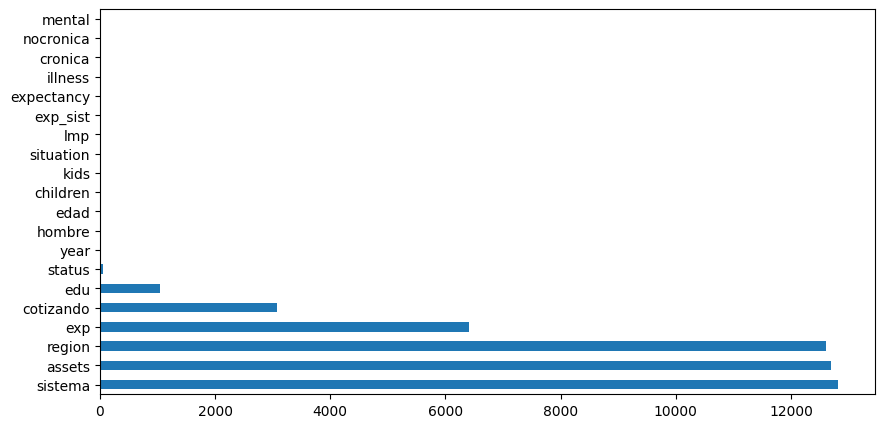

In [60]:
df_index_panel.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5))
df_index_panel.isna().sum().sort_values(ascending=False)

In [61]:
df_index_panel = df_index_panel.sort_index()

#Verificar si la educación baja en algún momento para cada persona
retrocesos = []

for folio, grupo in df_index_panel.groupby(level="folio_n20"):
    educ = grupo["edu"]
    if (educ.ffill().bfill().diff().dropna() < 0).any():
        retrocesos.append(folio)

# al final hubieron...
print(f"Se detectaron {len(retrocesos)} personas con retrocesos en nivel educativo.")


Se detectaron 8689 personas con retrocesos en nivel educativo.


In [62]:
df_retrocesos = df_index_panel.loc[retrocesos, ["edu"]]
print(df_retrocesos)


                   edu
folio_n20    time     
124560204870 2     7.0
             3     4.0
             4     5.0
             5     4.0
124560210408 1     4.0
...                ...
128124320664 4     3.0
128124342461 2     7.0
             4     5.0
128124411118 3     7.0
             4     3.0

[32407 rows x 1 columns]


In [63]:
df_index_panel.head(30)

year  edad  hombre   edu  region  status  kids  children  \
folio_n20    time                                                             
124560204870 2        4    49     0.0   7.0     5.0     3.0     1       1.0   
             3        6    51     0.0   4.0     5.0     3.0     1       1.0   
             4        9    54     0.0   5.0     5.0     3.0     1       1.0   
             5       12    57     0.0   4.0     NaN     5.0     0       0.0   
124560205935 1        2  1982     0.0  15.0    13.0     3.0     1       4.0   
             2        4  1984     0.0  15.0    13.0     3.0     1       3.0   
124560210408 1        2  1982     0.0   4.0    13.0     1.0     1       1.0   
             2        4  1984     0.0   4.0    13.0     1.0     0       0.0   
             3        6  1986     0.0   3.0    13.0     1.0     0       0.0   
             4        9  1989     0.0   3.0    13.0     3.0     0       0.0   
             5       12  1992     0.0   3.0     NaN     4.0     0       0.0   
124560216585 1        2  1982     0.0   7.0     5.0     3.0     1       1.0   
             2        4  1984     0.0   7.0     5.0     1.0     1       1.0   
             3        6  1986     0.0   7.0     5.0     1.0     1       1.0   
             4        9  1989     0.0   7.0     5.0     1.0     0       0.0   
124560229507 3        6    52     0.0   4.0    13.0     3.0     1       1.0   
             4        9    55     0.0   4.0    13.0     3.0     0       0.0   
             5       12    58     0.0   4.0     NaN     3.0     0       0.0   
124560233980 1        2  1982     0.0  14.0     5.0     2.0     0       0.0   
             4        9  1989     0.0   8.0     5.0     2.0     0       0.0   
             5       12  1992     0.0   2.0     NaN     3.0     0       0.0   
124560240157 1        2    48     1.0   3.0     6.0     5.0     0       0.0   
             2        4    50     1.0   3.0     6.0     5.0     0       0.0   
124560255777 1        2  1982     1.0   7.0    13.0     5.0     0       0.0   
             2        4  1984     1.0   3.0    13.0     5.0     0       0.0   
             4        9  1989     1.0   3.0    13.0     5.0     0       0.0   
             5       12  1992     1.0   3.0     NaN     5.0     0       0.0   
124560269622 1        2  1982     1.0   3.0     8.0     1.0     0       0.0   
             3        6  1986     1.0   1.0     8.0     1.0     0       0.0   
             4        9  1989     1.0   3.0     8.0     1.0     0       0.0   

                   situation  lmp   exp  sistema  cotizando       assets  \
folio_n20    time                                                          
124560204870 2             4    0   NaN      NaN        0.0        0.000   
             3             4    0   NaN      0.0        0.0        0.000   
             4             4    0   NaN      1.0        0.0        0.000   
             5             3    1   NaN      0.0        0.0          NaN   
124560205935 1             4    0   6.0      1.0        0.0   989038.060   
             2             4    0   6.0      1.0        0.0        0.000   
124560210408 1             3    1  22.0      1.0        1.0    89575.539   
             2             3    2  23.0      1.0        1.0        0.000   
             3             3    2  26.0      1.0        1.0   154486.300   
             4             3    2  29.0      1.0        1.0        0.000   
             5             4    0  29.0      1.0        1.0          NaN   
124560216585 1             3    1   8.0      0.0        0.0    56305.316   
             2             3    2  10.0      1.0        1.0   316794.380   
             3             3    2  13.0      1.0        0.0        0.000   
             4             3    1  16.0      1.0        1.0        0.000   
124560229507 3             3    2   NaN      NaN        0.0        0.000   
             4             3    2   NaN      NaN        0.0        0.000   
             5             3    2   NaN      1

In [64]:
# copia para manipular
df_copy = df_index_panel.copy()

# Aplicar fill dentro de cada folio para que NaN no interrumpa la secuencia
# Luego aplicar cummax para mantener o subir el nivel de educación
df_copy["edu_corrigida"] = (
    df_copy.groupby("folio_n20")["edu"]
           .transform(lambda x: x.ffill().cummax())
)

# Marcar las filas donde hubo cambio
df_copy["edu_cambiada"] = df_copy["edu"] != df_copy["edu_corrigida"]

# Mostrar las filas con cambios, restableciendo temporalmente el índice
cambios = df_copy[df_copy["edu_cambiada"]].reset_index()
print(cambios[["folio_n20", "time", "edu", "edu_corrigida"]])



          folio_n20  time  edu  edu_corrigida
0      124560204870     3  4.0            7.0
1      124560204870     4  5.0            7.0
2      124560204870     5  4.0            7.0
3      124560210408     3  3.0            4.0
4      124560210408     4  3.0            4.0
...             ...   ...  ...            ...
15814  128129656172     5  NaN            NaN
15815  128129920931     5  NaN            NaN
15816  128130184412     5  NaN            NaN
15817  128132196836     5  NaN            NaN
15818  128132701646     5  NaN            NaN

[15819 rows x 4 columns]


In [65]:
print("Se hicieron tanto cambios en educacion: ", sum(df_copy.edu_cambiada == True))
df_copy

Se hicieron tanto cambios en educacion:  15819


year  edad  hombre   edu  region  status  kids  children  \
folio_n20    time                                                             
124560204870 2        4    49     0.0   7.0     5.0     3.0     1       1.0   
             3        6    51     0.0   4.0     5.0     3.0     1       1.0   
             4        9    54     0.0   5.0     5.0     3.0     1       1.0   
             5       12    57     0.0   4.0     NaN     5.0     0       0.0   
124560205935 1        2  1982     0.0  15.0    13.0     3.0     1       4.0   
...                 ...   ...     ...   ...     ...     ...   ...       ...   
128133653188 5       12  1992     0.0  16.0     NaN     3.0     0       0.0   
128133692735 5       12  1992     0.0  12.0     NaN     2.0     0       0.0   
128133702320 5       12  1992     0.0  15.0     NaN     5.0     0       0.0   
128133728022 5       12  1992     0.0   8.0     NaN     2.0     0       0.0   
128133731927 5       12  1992     1.0   8.0     NaN     2.0     0       0.0   

                   situation  lmp  ...  cotizando     assets  exp_sist  \
folio_n20    time                  ...                                   
124560204870 2             4    0  ...        0.0       0.00         0   
             3             4    0  ...        0.0       0.00         0   
             4             4    0  ...        0.0       0.00         0   
             5             3    1  ...        0.0        NaN         0   
124560205935 1             4    0  ...        0.0  989038.06        19   
...                      ...  ...  ...        ...        ...       ...   
128133653188 5             4    0  ...        0.0        NaN         7   
128133692735 5             3    2  ...        1.0        NaN         7   
128133702320 5             4    0  ...        1.0        NaN         7   
128133728022 5             3    2  ...        1.0        NaN         6   
128133731927 5             3    2  ...        1.0        NaN         7   

                   expectancy  illness  cronica  nocronica  mental  \
folio_n20    time                                                    
124560204870 2           58.0      1.0      0.0        1.0     0.0   
             3           55.0      0.0      0.0        0.0     0.0   
             4           70.0      1.0      0.0        0.0     1.0   
             5           70.0      1.0      0.0        0.0     0.0   
124560205935 1           75.0      0.0      0.0        0.0     0.0   
...                       ...      ...      ...        ...     ...   
128133653188 5           80.0      0.0      0.0        0.0     0.0   
128133692735 5           80.0      1.0      0.0        0.0     0.0   
128133702320 5           75.0      0.0      0.0        0.0     0.0   
128133728022 5           70.0      1.0      0.0        0.0     0.0   
128133731927 5           90.0      0.0      0.0        0.0     0.0   

                   edu_corrigida  edu_cambiada  
folio_n20    time                               
124560204870 2               7.0         False  
             3               7.0          True  
             4               7.0          True  
             5               7.0          True  
124560205935 1              15.0         False  
...                          ...           ...  
128133653188 5              16.0         False  
128133692735 5              12.0         False  
128133702320 5              15.0         False  
128133728022 5               8.0         False  
128133731927 5               8.0         False  

[70255 rows x 22 columns]

<Axes: >

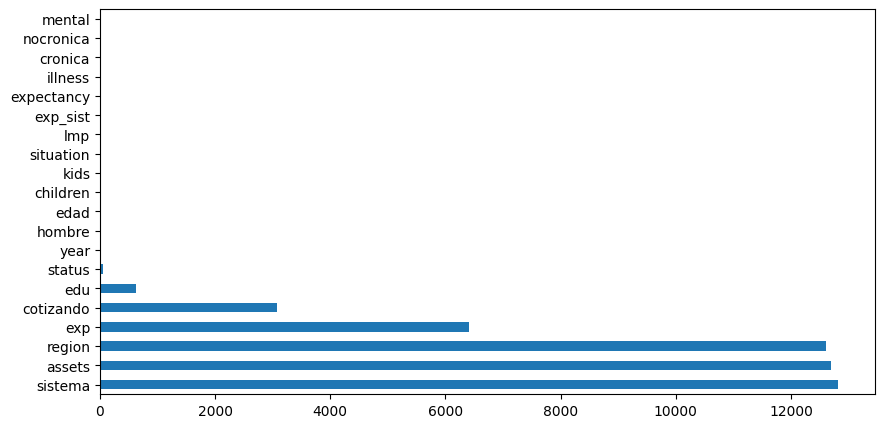

In [66]:
df_index_panel["edu"] = df_copy["edu_corrigida"]
df_index_panel.isna().sum().sort_values(ascending=False)[0:].plot(kind='barh', figsize=(10, 5))

#corregimos edu en el df, falta eliminar nans


In [67]:
#imputamos nans de educacion manteniendo el ultimo valor valido
df_index_panel["edu"].isna().sum()

np.int64(633)

In [68]:
df_nans_edu = df_index_panel[df_index_panel["edu"].isna()]
print(df_nans_edu.head(20))
print(f"Total de filas con NaN en edu: {len(df_nans_edu)}")

# la media en edu es:
print(df_index_panel["edu"].mean())



                   year  edad  hombre  edu  region  status  kids  children  \
folio_n20    time                                                            
124561218892 1        2    81     0.0  NaN     6.0     4.0     0       0.0   
124561425502 1        2  1983     1.0  NaN     9.0     2.0     0       0.0   
124561466966 1        2    74     1.0  NaN     8.0     1.0     0       0.0   
124561488763 1        2    72     0.0  NaN    13.0     4.0     0       0.0   
124561497425 1        2  1983     1.0  NaN    13.0     4.0     0       0.0   
124561604706 1        2    83     1.0  NaN     6.0     1.0     0       0.0   
124561622101 1        2    71     1.0  NaN     5.0     1.0     0       0.0   
124561633816 1        2  1983     1.0  NaN    13.0     1.0     0       0.0   
124561697574 1        2  1983     0.0  NaN     7.0     4.0     0       0.0   
124561817422 1        2  1983     1.0  NaN     7.0     2.0     0       0.0   
124561901841 1        2    73     1.0  NaN     9.0     1.0     0

In [69]:
df_index_panel["edu"].isna().sum()

np.int64(633)

In [70]:
df_index_panel["edu_sin_nans"]= df_index_panel["edu"].fillna(8)

In [71]:
df_index_panel["edu_sin_nans"].isna().sum()
df_index_panel["edu_sin_nans"].value_counts(1)

edu_sin_nans
8.0     0.151164
3.0     0.117728
12.0    0.112633
7.0     0.094769
4.0     0.090001
17.0    0.066458
18.0    0.052608
1.0     0.049135
15.0    0.044324
11.0    0.037506
16.0    0.035257
5.0     0.031215
2.0     0.030831
14.0    0.018148
6.0     0.016340
13.0    0.014647
9.0     0.012198
0.0     0.012184
19.0    0.010078
10.0    0.002776
Name: proportion, dtype: float64

In [72]:
print("usamos edu_sin_nans para el modelo")
print("numero de nans en edu: ",df_index_panel["edu_sin_nans"].isna().sum(),"\n", df_index_panel["edu"].value_counts())

usamos edu_sin_nans para el modelo
numero de nans en edu:  0 
 edu
8.0     9987
3.0     8271
12.0    7913
7.0     6658
4.0     6323
17.0    4669
18.0    3696
1.0     3452
15.0    3114
11.0    2635
16.0    2477
5.0     2193
2.0     2166
14.0    1275
6.0     1148
13.0    1029
9.0      857
0.0      856
19.0     708
10.0     195
Name: count, dtype: int64


miramos el df


In [73]:
df_index_panel

year  edad  hombre   edu  region  status  kids  children  \
folio_n20    time                                                             
124560204870 2        4    49     0.0   7.0     5.0     3.0     1       1.0   
             3        6    51     0.0   7.0     5.0     3.0     1       1.0   
             4        9    54     0.0   7.0     5.0     3.0     1       1.0   
             5       12    57     0.0   7.0     NaN     5.0     0       0.0   
124560205935 1        2  1982     0.0  15.0    13.0     3.0     1       4.0   
...                 ...   ...     ...   ...     ...     ...   ...       ...   
128133653188 5       12  1992     0.0  16.0     NaN     3.0     0       0.0   
128133692735 5       12  1992     0.0  12.0     NaN     2.0     0       0.0   
128133702320 5       12  1992     0.0  15.0     NaN     5.0     0       0.0   
128133728022 5       12  1992     0.0   8.0     NaN     2.0     0       0.0   
128133731927 5       12  1992     1.0   8.0     NaN     2.0     0       0.0   

                   situation  lmp  ...  sistema  cotizando     assets  \
folio_n20    time                  ...                                  
124560204870 2             4    0  ...      NaN        0.0       0.00   
             3             4    0  ...      0.0        0.0       0.00   
             4             4    0  ...      1.0        0.0       0.00   
             5             3    1  ...      0.0        0.0        NaN   
124560205935 1             4    0  ...      1.0        0.0  989038.06   
...                      ...  ...  ...      ...        ...        ...   
128133653188 5             4    0  ...      1.0        0.0        NaN   
128133692735 5             3    2  ...      1.0        1.0        NaN   
128133702320 5             4    0  ...      1.0        1.0        NaN   
128133728022 5             3    2  ...      1.0        1.0        NaN   
128133731927 5             3    2  ...      1.0        1.0        NaN   

                   exp_sist  expectancy  illness  cronica  nocronica  mental  \
folio_n20    time                                                              
124560204870 2            0        58.0      1.0      0.0        1.0     0.0   
             3            0        55.0      0.0      0.0        0.0     0.0   
             4            0        70.0      1.0      0.0        0.0     1.0   
             5            0        70.0      1.0      0.0        0.0     0.0   
124560205935 1           19        75.0      0.0      0.0        0.0     0.0   
...                     ...         ...      ...      ...        ...     ...   
128133653188 5            7        80.0      0.0      0.0        0.0     0.0   
128133692735 5            7        80.0      1.0      0.0        0.0     0.0   
128133702320 5            7        75.0      0.0      0.0        0.0     0.0   
128133728022 5            6        70.0      1.0      0.0        0.0     0.0   
128133731927 5            7        90.0      0.0      0.0        0.0     0.0   

                   edu_sin_nans  
folio_n20    time                
124560204870 2              7.0  
             3              7.0  
             4              7.0  
             5              7.0  
124560205935 1             15.0  
...                         ...  
128133653188 5             16.0  
128133692735 5             12.0  
128133702320 5             15.0  
128133728022 5              8.0  
128133731927 5              8.0  

[70255 rows x 21 columns]

In [74]:
print(df_index_panel["edu_sin_nans"].isna().sum(),
df_index_panel["edu"].isna().sum())

0 633


# Lista variables revisadas
1) si
2) region(descartada por trato)
3) si
4) si
5) dinero(assets) lo mismo que 2)
6) educacion -> si
7) si
8) si


# Fin limpieza nan y  demas cosas para variables nominadas

# columnas a usar finalmente
- expectancy
- edu_sin_nans
- hombre
- kids
- Children
- illness
- cronica
- no cronica
- mental


# finalizamos cambios y ajustes relacionados a limpieza

In [75]:
df_index_panel.dtypes


year              int64
edad              int64
hombre          float64
edu             float64
region          float64
status          float64
kids              int64
children        float64
situation         int64
lmp               int64
exp             float64
sistema         float64
cotizando       float64
assets          float64
exp_sist          int64
expectancy      float64
illness         float64
cronica         float64
nocronica       float64
mental          float64
edu_sin_nans    float64
dtype: object

In [76]:
df_index_panel["illness"]=df_index_panel["illness"].astype(int)
df_index_panel["cronica"]=df_index_panel["cronica"].astype(int) 
df_index_panel["nocronica"]=df_index_panel["nocronica"].astype(int)
df_index_panel["mental"]=df_index_panel["mental"].astype(int)
df_index_panel["hombre"]=df_index_panel["hombre"].astype(int)
df_index_panel["edu_sin_nans"]=df_index_panel["edu_sin_nans"].astype(int)

In [77]:
df_index_panel.dtypes

year              int64
edad              int64
hombre            int64
edu             float64
region          float64
status          float64
kids              int64
children        float64
situation         int64
lmp               int64
exp             float64
sistema         float64
cotizando       float64
assets          float64
exp_sist          int64
expectancy      float64
illness           int64
cronica           int64
nocronica         int64
mental            int64
edu_sin_nans      int64
dtype: object

In [78]:
df_index_panel.isna().sum().sort_values(ascending=False)

sistema         12818
assets          12697
region          12610
exp              6404
cotizando        3078
edu               633
status             59
year                0
hombre              0
edad                0
situation           0
kids                0
children            0
lmp                 0
exp_sist            0
expectancy          0
illness             0
cronica             0
nocronica           0
mental              0
edu_sin_nans        0
dtype: int64

# Resumen pregunta 1

elegimos las variables: por ser mas manejables y sin ejercer supuestos mayores como seria el caso de region:


- para hombre borramos nans
- para kids y children ajustamos inconsistencias logicas como tener hijos y tener 0 hijos, o no tener hijos y tener >0 hijos
- para expectancy, correjimos valores outliers
- para illnes y las 3 enfermedades ajustamos casos de full nans(como 0, osea respuestas en blanco), ademas de dejar en 0 todas si illnes era 0 o nan
- para edu imputamos valores promedio en casos full nan, y ajustamos a que los años de educacion no disminuyan por ronda
-  a la brevedad se incorporan dummies de year





# PREGUNTA 1

# PREGUNTA 2

In [79]:
print(len(df_index_panel.columns))
df_index_panel.columns

21


Index(['year', 'edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental',
       'edu_sin_nans'],
      dtype='object')

In [80]:
df_duumies_para_arreglar_grafico= df_index_panel.copy()
df_duumies_para_arreglar_grafico=pd.get_dummies(df_duumies_para_arreglar_grafico, columns=["year"], drop_first=True)
#el valor 2 d eyear quedo com referencia 
df_index_panel1 = df_duumies_para_arreglar_grafico.copy()

In [81]:
# MODELO POLS AGRUPADO

y=df_index_panel1["expectancy"]
X=df_index_panel1[["hombre", "edu_sin_nans","kids", "children","illness", "cronica", "nocronica", "mental","year_4", "year_6", "year_9", "year_12"]]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0923
Estimator:                   PanelOLS   R-squared (Between):              0.0421
No. Observations:               70255   R-squared (Within):               0.1372
Date:                Tue, May 20 2025   R-squared (Overall):              0.0923
Time:                        21:35:25   Log-likelihood                -2.685e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      595.36
Entities:                       25849   P-value                           0.0000
Avg Obs:                       2.7179   Distribution:                F(12,70242)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             595.36
                            

Respuesta 2:
explica poco, alrededor de 10%

Con repecto a su significancia:
lo son: 
- hombre
- kids
- children
- illness
- cronica
- mental
- edu_sin_nans(años de educacion)
- dummies de year
no lo son:
- no cronica

luego los valores positivos indican un aumento en la expectativa de vida autoreportada en promedio por las personas, donde aumenta(o baja) en la magnitud de la variable correspondiente, conforme:
por ejemplo:
para variables categoricas:
- hombre:  si es hombre(aumenta 1 año)
- cronica: si tiene una enfermedad cronica(aumenta 2 años, lo cual parece extraño, debe ser por el modelo utilizado, el cual replica a las personas, esto porque como se agrupa por ronda, y cronica se mantiene para la persona, pareciera que hay= esa persona * rondas, de personas que dijeron tal edad y tiene enfermedad cronica)

para variables numericas:
- kids:(en este caso baja) si aumenta en una unidad el numero de niños que tiene una persona en promedio la expectativa de vida baja, lo mismo para kids(pero con el hecho de tener hijos) mas su efecto es mucho menor, es una variacion negativa baja hacia la expectativa de vida.

notar que para educacion el efecto es minimo, ademas de ser negativo(posible efecto similar al de cronica, al no variar mucho en varios casos, para el mismo individuo)

luego si nos fijamos en el año notemos que todos indican un aumento, mas las personas que respondieron en year9 tiene una variacion mucho mal alta que los demas años (__year 9 ALTO__)





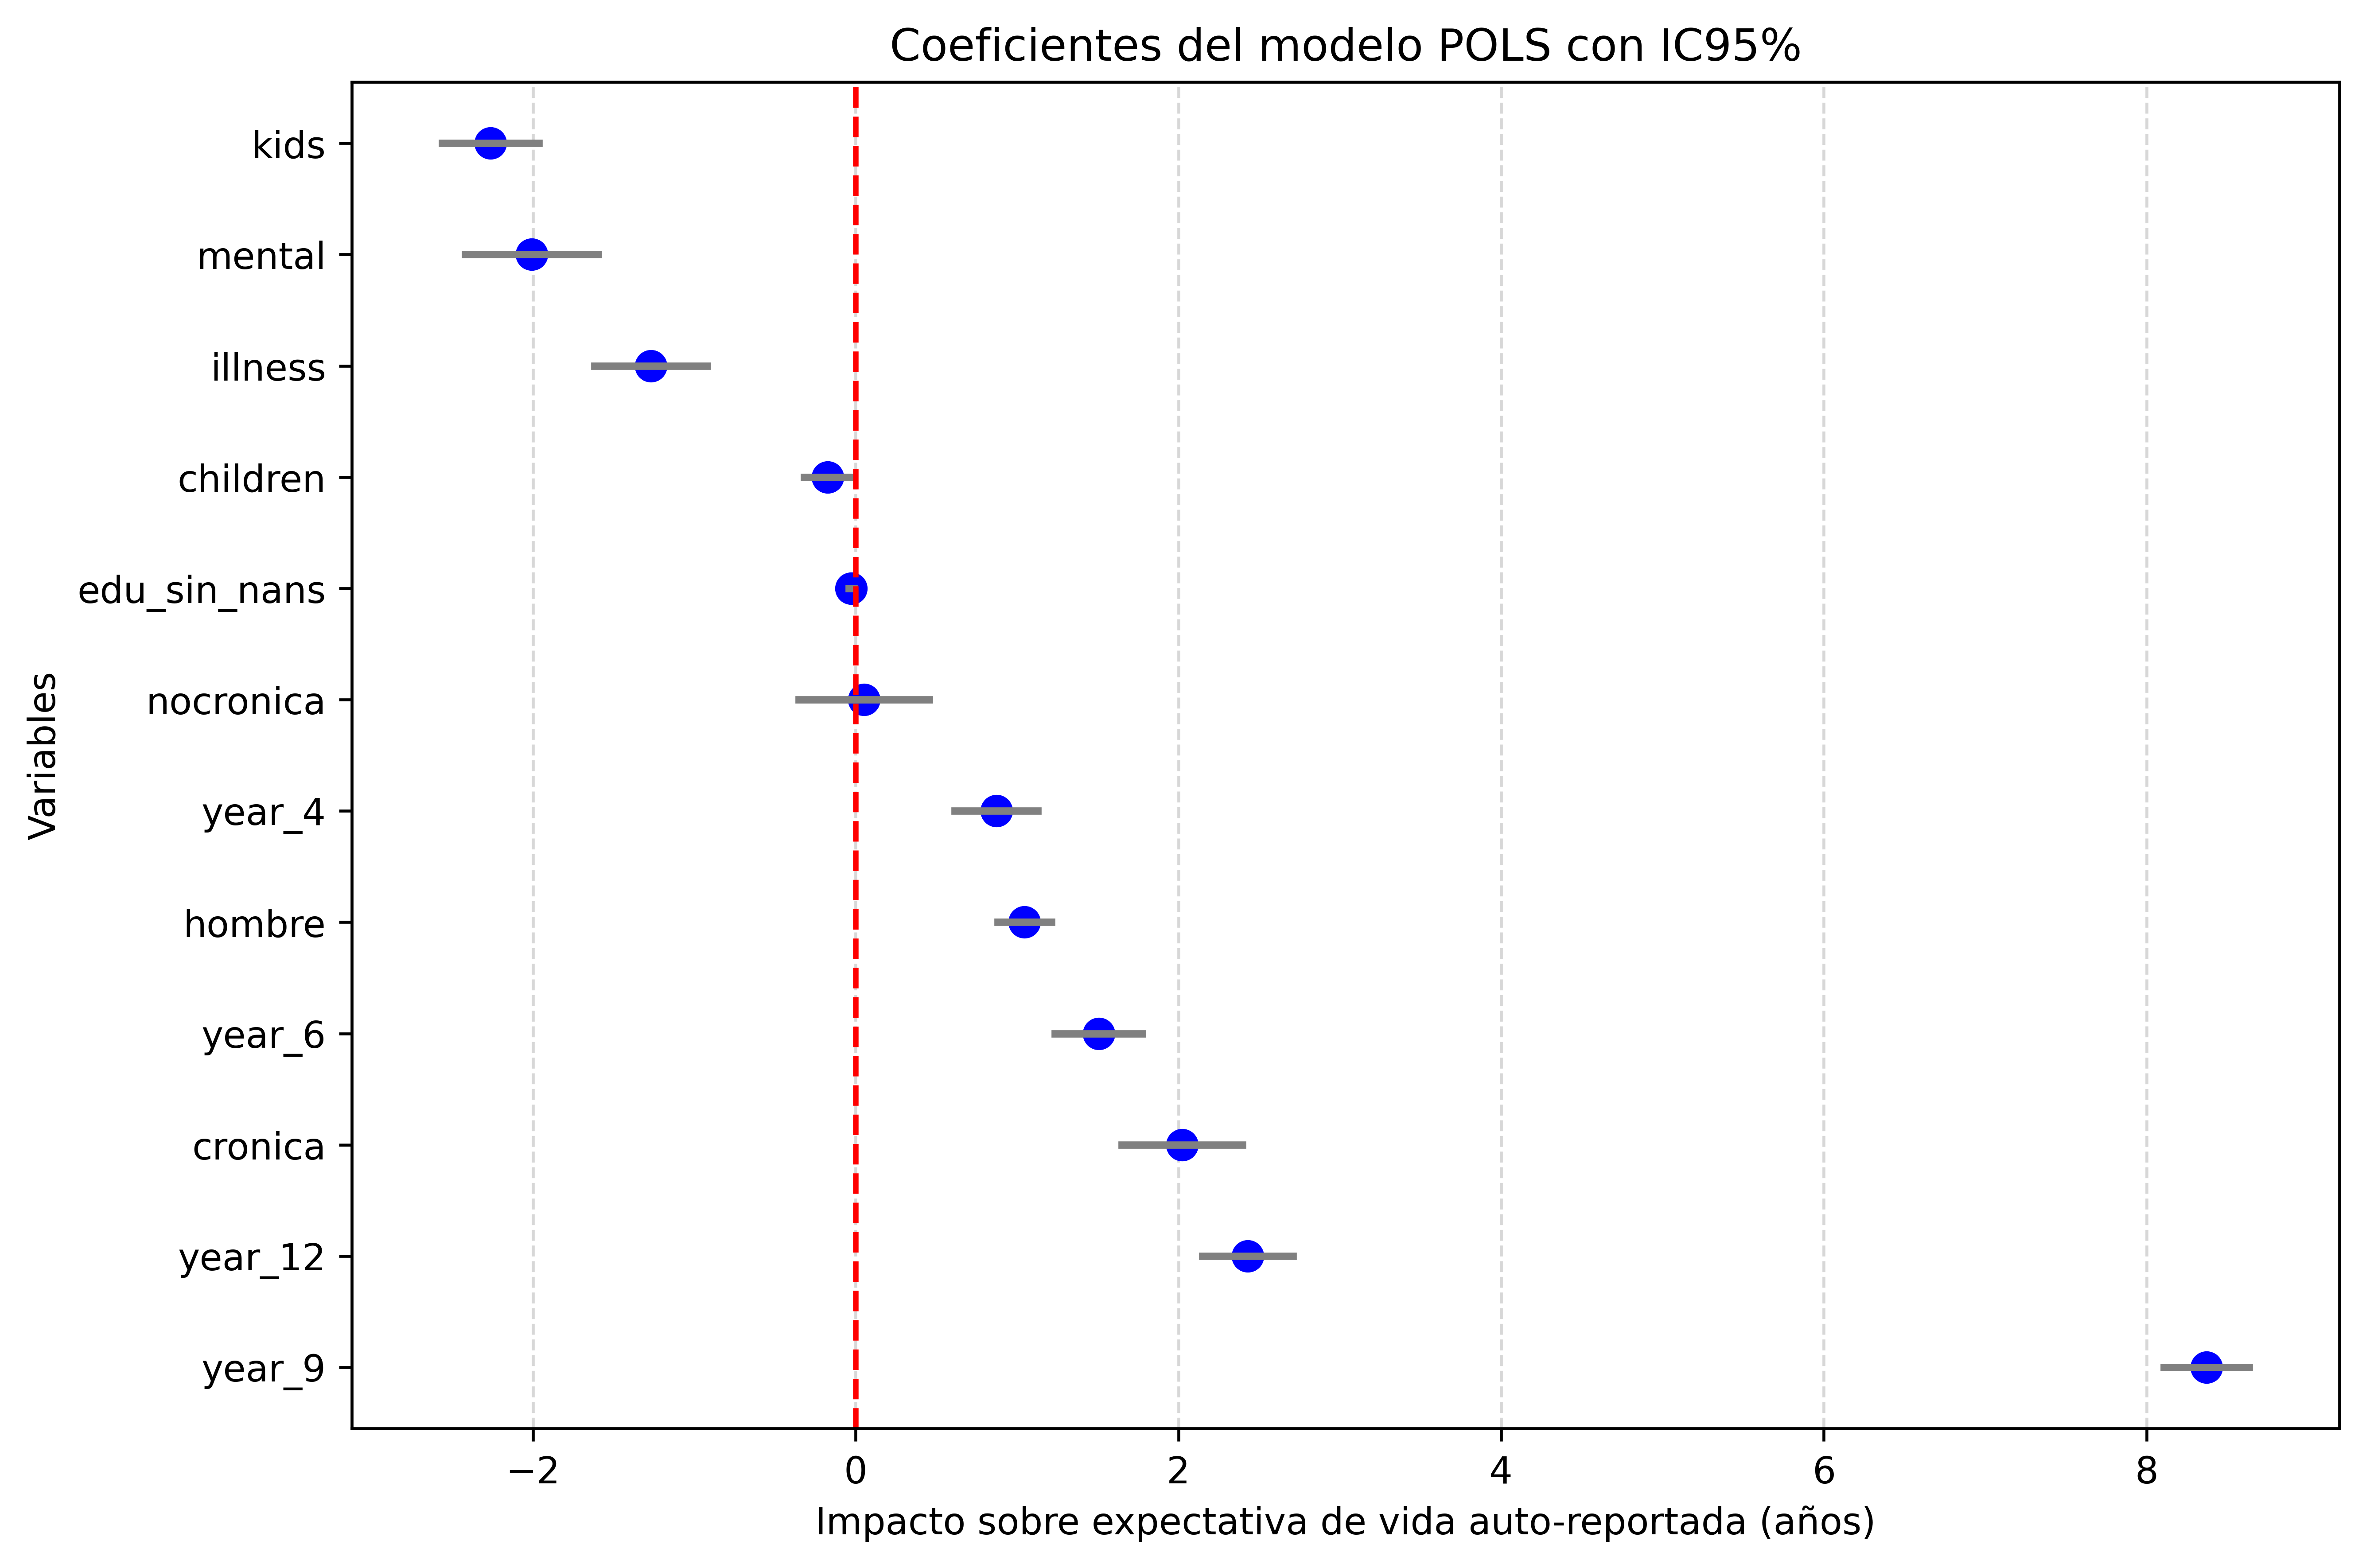

In [ ]:
coef_df = pd.DataFrame({
    'variable': ['hombre', 'edu_sin_nans', 'kids', 'children', 'illness',
                 'cronica', 'nocronica', 'mental', 'year_4', 'year_6', 'year_9', 'year_12'],
    'coef': [1.0461, -0.0267, -2.2632, -0.1736, -1.2687,
             2.0225, 0.0511, -2.0078, 0.8720, 1.5062, 8.3712, 2.4298],
    'lower': [0.8800, -0.0426, -2.5621, -0.3193, -1.6171,
              1.6486, -0.3521, -2.4199, 0.6151, 1.2353, 8.1070, 2.1494],
    'upper': [1.2123, -0.0107, -1.9643, -0.0278, -0.9203,
              2.3965, 0.4544, -1.5957, 1.1289, 1.7770, 8.6354, 2.7102]
})

# Ordenamos coeficientes
coef_df = coef_df.sort_values('coef')

# Gráfico
plt.figure(figsize=(9, 6), dpi=600)
sns.pointplot(data=coef_df, x="coef", y="variable", join=False, color="blue")
for i in range(coef_df.shape[0]):
    plt.plot([coef_df['lower'].iloc[i], coef_df['upper'].iloc[i]], 
             [i, i], color='gray', lw=2)
plt.axvline(0, color='red', linestyle='--')
plt.title("Coeficientes del modelo POLS con IC95%")
plt.xlabel("Impacto sobre expectativa de vida auto-reportada (años)")
plt.ylabel("Variables")
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# PREGUNTA 3

In [110]:
df_duumies_para_arreglar_grafico= df_index_panel.copy()
df_duumies_para_arreglar_grafico=pd.get_dummies(df_duumies_para_arreglar_grafico, columns=["year"], drop_first=True)
#el valor 2 d eyear quedo com referencia 
df_index_panel1 = df_duumies_para_arreglar_grafico.copy()

In [111]:
#Elegimos variables que en la data varian con el tiempo para las personas
X = df_index_panel1[['hombre', 'edu_sin_nans', 'kids', 'children', 'illness', 'cronica', 'nocronica', 'mental', 'year_4', 'year_6', 'year_9', 'year_12']]  #
y = df_index_panel1["expectancy"]
X=sm.add_constant(X)
# Paso 3: Ajustar modelo con efectos fijos
model = lmp.PanelOLS(y, X, entity_effects=True, drop_absorbed=True)
fe = model.fit(cov_type="robust")
print(fe)




                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.1466
Estimator:                   PanelOLS   R-squared (Between):             -0.0114
No. Observations:               70255   R-squared (Within):               0.1466
Date:                Tue, May 20 2025   R-squared (Overall):              0.0698
Time:                        22:29:42   Log-likelihood                -2.423e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      693.45
Entities:                       25849   P-value                           0.0000
Avg Obs:                       2.7179   Distribution:                F(11,44395)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             499.48
                            

Respuesta pregunta 3:

------------------------------------------------------------------

EL modelo explica poco de los datos(14%), pero un poco mas que el anterior, en particular notemos que 4 variables no son significativas esta vez, las cuales son:

 los años de educacion(edu_sin_nans), el hecho de tener un hijo(kids), el numero de hijos(children) y tener una enfermedad cronica.

Por otro lado, el efecto de tener una enfermedad cronica ahora indica una relacion negativa con la expectativa de vida autoreportada. los años de educacion ahora tienen una relacion positiva.

-luego el hecho de tener hijos, y mientras mas hijos se tenga, solo por ese factor aislado, una persona se auto reporta con una expectativa de    vida mas baja.

kids subio un poco en su efecto marginal(magnitud), en cambio ahora es positivo y mas bajo (estos cambios en magnitud).

luego notemos que el efecto de la variable hombre se ve absorvido en el modelo, esto porque el genero de una persona no cambia.

notemos ademas que si bien el efecto de la educacion marginalmente es bajo,para una mejor ilustracion, tomemos el caso entre 8 años(educacion basica) y 17(universitaria) con 9 años de diferencia, habria una diferencia de(9*0.05) años en la expectativa de vida autoreportada, esto es medio años aprox. por lo cual varia, pero bastante poco. mas si fuera una persona con basica de primer ciclo(4) versus una persona con nivel universitario(17), la diferencia es de casi 13 años, algo mas considerable, pero no tan representativo, pues la media es de entre 8 y 9 años.
ademas el efecto igual sigue siendo bajo( 0,65: medio año aprox)


-------------------------

_________________________



In [113]:
print(0.05*9,
0.05*13)

0.45 0.65


In [86]:
#la media de años de educacion es:
print(df_index_panel["edu_sin_nans"].mean())

8.794164116432993


# PREGUNTA 4

In [87]:
df_duumies_para_arreglar_grafico= df_index_panel.copy()
df_duumies_para_arreglar_grafico=pd.get_dummies(df_duumies_para_arreglar_grafico, columns=["year"], drop_first=True)
#el valor 2 d eyear quedo com referencia 
df_index_panel1 = df_duumies_para_arreglar_grafico.copy()

In [88]:
df_index_panel1.columns

Index(['edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental',
       'edu_sin_nans', 'year_4', 'year_6', 'year_9', 'year_12'],
      dtype='object')

In [89]:
from linearmodels.panel import RandomEffects
y = df_index_panel1["expectancy"]
X = df_index_panel1[["hombre", "edu_sin_nans", "kids", "children", 
          "illness", "cronica", "nocronica", "mental", "year_4", "year_6", "year_9", "year_12"]]

# Modelo de efectos aleatorios
re_model = RandomEffects(y, X)
re_result = re_model.fit(cov_type="robust")

# Mostrar resultados
print(re_result.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.7009
Estimator:              RandomEffects   R-squared (Between):              0.8285
No. Observations:               70255   R-squared (Within):              -0.2236
Date:                Tue, May 20 2025   R-squared (Overall):              0.8239
Time:                        21:35:26   Log-likelihood                -2.795e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.372e+04
Entities:                       25849   P-value                           0.0000
Avg Obs:                       2.7179   Distribution:                F(12,70243)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):          1.884e+04
                            

In [ ]:
a=df_index_panel1.groupby(["expectancy"]).agg({"hombre": ["count", "unique","mean"]})
a.head(50)

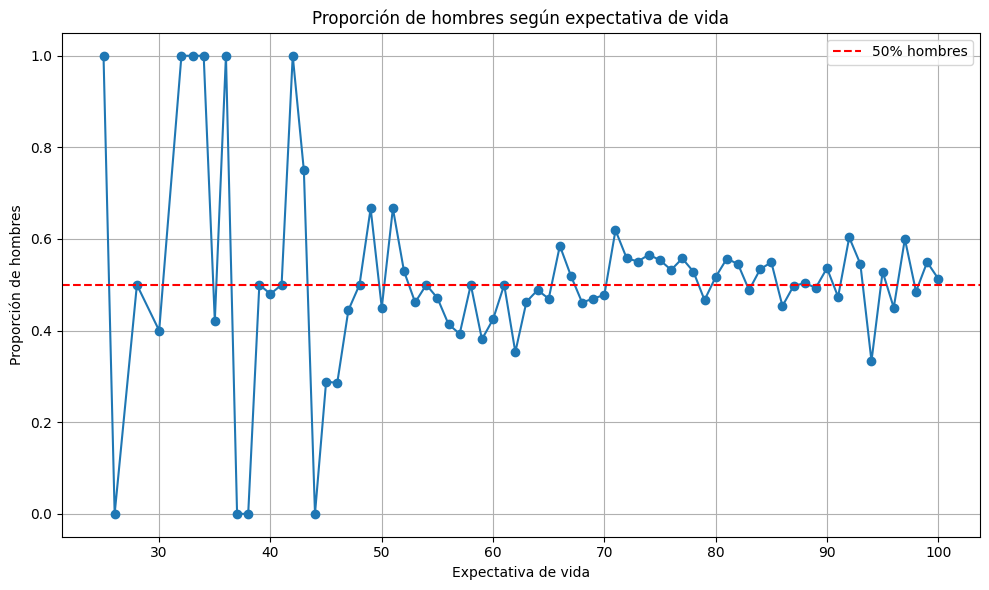

In [91]:

a_plot = a.copy()
a_plot.columns = ['count', 'unique', 'mean_hombre']

plt.figure(figsize=(10,6))
plt.plot(a_plot.index, a_plot['mean_hombre'], marker='o', linestyle='-')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% hombres')  

plt.title("Proporción de hombres según expectativa de vida")
plt.xlabel("Expectativa de vida")
plt.ylabel("Proporción de hombres")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


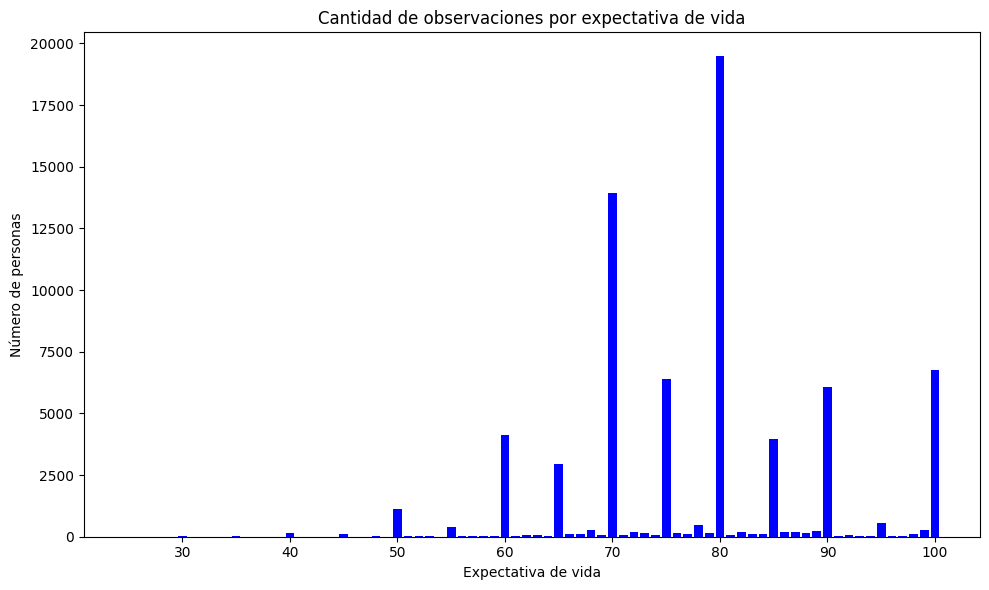

In [92]:
plt.figure(figsize=(10,6))
plt.bar(a_plot.index, a_plot['count'], color='blue')
plt.title("Cantidad de observaciones por expectativa de vida")
plt.xlabel("Expectativa de vida")
plt.ylabel("Número de personas")
plt.tight_layout()
plt.show()



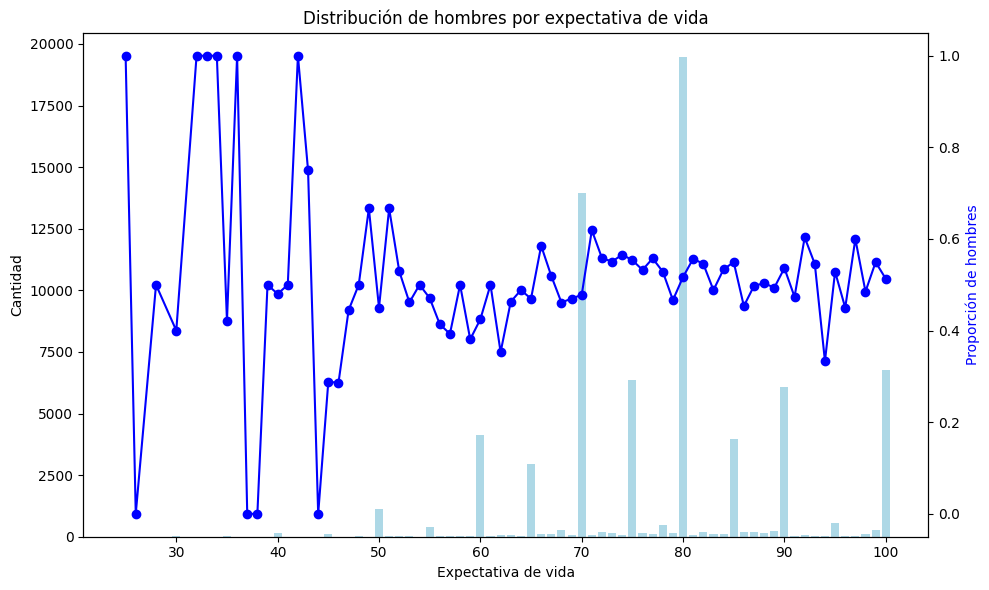

In [93]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Eje 1: count
ax1.bar(a_plot.index, a_plot['count'], color='lightblue')
ax1.set_xlabel("Expectativa de vida")
ax1.set_ylabel("Cantidad", color='black')

# Eje 2: proporción de hombres
ax2 = ax1.twinx()
ax2.plot(a_plot.index, a_plot['mean_hombre'], color='blue', marker='o')
ax2.set_ylabel("Proporción de hombres", color='blue')

plt.title("Distribución de hombres por expectativa de vida")
fig.tight_layout()
plt.show()


Respuesta pregunta 4:

Notemos en particular que hay un patron en las respuestas de expectativas de vida, la gente suele en general estimar en multiplos de 10(y tambien de 5, pero se concentra mas en los de 10), pues la frecuencia de esta se puede ver marcada en el grafico en aquellos numeros.

Luego por parte de este modelo, se asume que las variables no estan correlacionados con los efectos no observables individuales, ademas recordemos que este modelo tiene en cuenta la relacion de la data entre individuos e intra individuos(a lo largo de las rondas(tiempo))

luego si lo que asumimos no se cumple puede que el modelo de resultados sesgados, que no son como se ve a primera vista. esto si por ejemplo la variable educacion esta asociada a un efecto individual no observado como el dinero de la familia de esa persona(que es un factor importante para el tratamiento de problemas de salud y para acceder con mayor facilidad a niveles educativos mas altos, y para el caso de la educacion media y basicos, uno de mayor calidad), ademas puede que el numero de hijos incluya para cada individuo, en las rondas, el gasto economico que trae consigo y que este puede provocar un estres si es elevado en comparacion con el sueldo mensual de la persona. En resumen, la calidad de vida no observada puede afectar el valor esperado de vida de los individuos.

En resumen puede andar bien, pero requiere de varios supuestos como los anteriormente mencionados(a modo de ilustrar netamente)
que hablan de la no correlacion de las variables con los efectos individuales no observados.

Notemos que en este caso se explica bastante, mas hay que tener en consideracion el supuesto antes dicho.

- En cuanto a variables: 

- todas significativas, menos cronica y mental.

- hombre parece afectar mucho, lo cual es peculiar(hombres optmistas?)

- el efecto de educacion aumentó, ahora de 3,36 por año de educacion, lo cual es bastante considerable si realizamos el ejercicio anterior(el dicho en efecto fijo)

- el hecho de tener hijos aumento, y el de numero de hijos ahora es positivo

- ahora cronica es posito, mental y no cronica se mantienen en "signo"

- el efecto del año es mayor para year 9, ademas ahora no esta "solo", sino que year 12 igual presenta una alza a un nivel similar que year 9, los demas siguen en comparacion mas bajos


(nota para el autor: hasta ahora year 9 y 12 fijo)










# PREGUNTA 5

In [ ]:
#### este test si  ##########
#### este siiiiii  ##########
#############################

#En estos casos el RE es mejor que el FE, pero para ello necesitamos analizar la correlación entre los efectos individuales y las variables explicativas.
#mediante un test, para descartar.

import numpy.linalg as la
from scipy import stats

# Prepara los parámetros y matrices de covarianza SIN la constante
fe_params = fe.params.drop('const')
fe_cov = fe.cov.drop('const', axis=0).drop('const', axis=1)



# Asegura que FE y RE tengan las mismas variables
common = fe_params.index.intersection(re_result.params.index)
fe_params = fe_params[common]
fe_cov = fe_cov.loc[common, common]
re_params = re_result.params[common]
re_cov = re_result.cov.loc[common, common]

#print("coomon: ", common)
#print("Parametros FE:\n", fe_params)
#print("Covarianza FE:\n", fe_cov)
#print("Parametros RE:\n", re_params)
#print("Covarianza RE:\n", re_cov)


# Define y corre el test de Hausman
def hausman(params_fe, cov_fe, params_re, cov_re):
    diff = params_fe - params_re
    psi = cov_fe - cov_re
    dof = diff.size
    W = diff.T @ la.inv(psi) @ diff
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval

# Ejecuta el test
htest = hausman(fe_params, fe_cov, re_params, re_cov)

print("resultados del test de Hausman: \n \n")
print("Hausman Test: chi-2 = {:.4f}, df = {}, p-value = {:.4f}".format(*htest))


resultados del test de Hausman: 
 

Hausman Test: chi-2 = 24079.0549, df = 11, p-value = 0.0000


Respuesta pregunta 5: 

- Con respecto a las diferencias, estas existen diferencias a traves de los modelos por la forma que tratan la data. para el caso del __pools agrupado__ se trata cada fila como una observacion, lo cual no tiene mucho sentido si se quiere tomar en cuenta el efecto del tiempo, por ello analiza de una forma inexacta para este caso, pues en realidad no hay varios hombres por ejemplos, sino que era el mismo pero en diferentes observaciones, al igual con otras variables, lo cual es mas problematico en caso de variables mas fijas, pues hace parecer que hay mas individuos con estas caracteristicas cuando en realidad no es asi, asi si los hombre por ejemplo respondieran mas rondas(variable time)podria indicar que hay mas hombres,etc.

- Luego para el caso del modelo de __efecto fijo__, este analiza por individuos, donde ve cuales son los cambios entre esa misma entidad, más tiene la desventaja que si bien ve por el tiempo, como es el mismo individuo, dada la anturaleza de ciertas variables como educacion, genero, etc, estas no varian a lo largo del perido de estudio(laas rondas) por lo cual no aportan mucho al modelo, y este las podria absorber(como el caso de hombre).

- El caso del modelo de __efecto aleatorio__, es en palabras simples una mezcla equilibrada de los 2 anteriores, más dado que trabaja de ambas maneras, su requisito, o supuesto para que este funcione es bien delicado, pues pide que no haya correlacion de las variables explicativas intra individuos, lo cual suele pasar pues hay variables que pueden ser alteradas por otras, otras que no estan siendo observadas, por lo cual se les atribuye un significado erroneo a estas variables explicativas que si presentan esta correlacion. En resumen, el modelo no es consistente en estos casos. 

- Luego dada que la data es un panel no balanceado, que es una data que precisa de analizar a lo largo de instancias de tiempo, y que una cantidad de variables son fijas en el tiempo...el modelo de efectos fijos y aleatorios quedan como candidatos, aparentemente el modelo de efectos aleatorios presentaba una buena situacion, pero despues de aplicar el test de hausman, se dio cuenta que el modelo de efecto aleatorio no cumplia con su supuesto(la hipotesis nula se rechazó), por lo que el mas __indicado__ seria teoricamente el de __efecto fijo__ .

. Las variables que resultaron ser robustas son:

- year 9 y 12, los cuales siempre tuvieron una relacion positiva y un efecto mas considerable en la expectativa de vida autoreportada de los individuos.



# PREGUNTA 6

# MODIFICACION IMPORTANTE, AÑADIMOS YEAR COMO DUMMIE

In [99]:
df_duumies_para_arreglar_grafico= df_index_panel.copy()
df_duumies_para_arreglar_grafico=pd.get_dummies(df_duumies_para_arreglar_grafico, columns=["year"], drop_first=True)
#el valor 2 d eyear quedo com referencia 


In [100]:
df_duumies_para_arreglar_grafico.columns

Index(['edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
       'expectancy', 'illness', 'cronica', 'nocronica', 'mental',
       'edu_sin_nans', 'year_4', 'year_6', 'year_9', 'year_12'],
      dtype='object')

In [101]:
#######################
###

df_index_panel1 = df_duumies_para_arreglar_grafico.copy()

#mis columnas del dataframe 
# Index(['edad', 'hombre', 'edu', 'region', 'status', 'kids', 'children',
#       'situation', 'lmp', 'exp', 'sistema', 'cotizando', 'assets', 'exp_sist',
#       'expectancy', 'illness', 'cronica', 'nocronica', 'mental',
#       'edu_sin_nans', 'year_4', 'year_6', 'year_9', 'year_12'],
#      dtype='object')

import statsmodels.api as sm
from linearmodels.panel import RandomEffects

# aqui usamos el data con dummies de year
X = df_index_panel1.drop(['expectancy', 'year_4', 'year_6', 'year_9', 'year_12', 'edu', 'status', 'region','assets'], axis=1, inplace=False)
Xm = X.groupby(by = 'folio_n20').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(df_index_panel1,Xm, left_index=True, right_index=True)
Y = Xc['expectancy']
X = Xc[['hombre', 'edu_sin_nans', 'kids', 'children', 'illness', 'cronica', 'nocronica', 'mental','medu_sin_nans','mkids', 'mchildren', 'millness', 'mcronica', 'mnocronica','mmental', 'year_4', 'year_6', 'year_9', 'year_12']]
X=sm.add_constant(X)

model=RandomEffects(Y,X, check_rank=False)
cre=model.fit(cov_type="robust")
print(cre)









                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3503
Estimator:              RandomEffects   R-squared (Between):              0.0436
No. Observations:               70255   R-squared (Within):               0.1444
Date:                Tue, May 20 2025   R-squared (Overall):              0.0969
Time:                        21:48:43   Log-likelihood                -2.589e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1993.2
Entities:                       25849   P-value                           0.0000
Avg Obs:                       2.7179   Distribution:                F(19,70235)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             378.74
                            

In [102]:
# Variables que se usarán
#X = df_index_panel1[['hombre', 'edu_sin_nans', 'kids', 'children', 'illness', 'cronica', 'nocronica', 'mental', 'year_4', 'year_6', 'year_9', 'year_12']]

# Variables que sí varían: excluimos 'hombre' al calcular medias por grupo
#X_varying = X.drop(columns=['hombre'])

# Calcular medias por grupo (por folio_n20, nuestro id)
#Xm = X_varying.groupby(level='folio_n20').transform('mean')
#Xm.columns = ['m_' + col for col in Xm.columns]

# Concatenar variables originales + medias
#X_cre = pd.concat([X, Xm], axis=1)
#X_cre = sm.add_constant(X_cre)

# Variable dependiente
#y = df_index_panel1['expectancy']
#y.index = df_index_panel1.index  # asegurar que tengan el mismo índice

# Ajustar modelo de efectos aleatorios correlacionados
#model = RandomEffects(y, X_cre, check_rank=False)
#cre_result = model.fit(cov_type="robust")

# resultados
#print(cre_result.summary)

In [103]:
print(lmp.compare({"FE": fe, "RE": re_result, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 70255             70255             70255
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.1466            0.7009            0.3503
R-Squared (Within)              0.1466           -0.2236            0.1444
R-Squared (Between)            -0.0114            0.8285            0.0436
R-Squared (Overall)             0.0698            0.8239            0.0969
F-statistic                     693.45         1.372e+04            1993.2
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

Respuesta pregunta 6:

este modelo es mas adecuado que el modelo re tradicional, dado que en este caso si habia un componente no observado, el cual a traves del prmomedio para las variables explicativas pertinentes se amortiza ese efecto, permitiendo aislar mas el efecto real que tiene las variables explicativas a nivel intra individuo, y tambien mostrar (con los promedios) un panorama general de que sucede entre individuos. Luego el modelo explica pero no tanto, por lo que quizas se debe a la poca variabilidad segun el trato de datos en especifico. ademas existe la posibilidad que hayan factores exogenos al modelo que tengan un efecto contundente.


# PREGUNTA 7

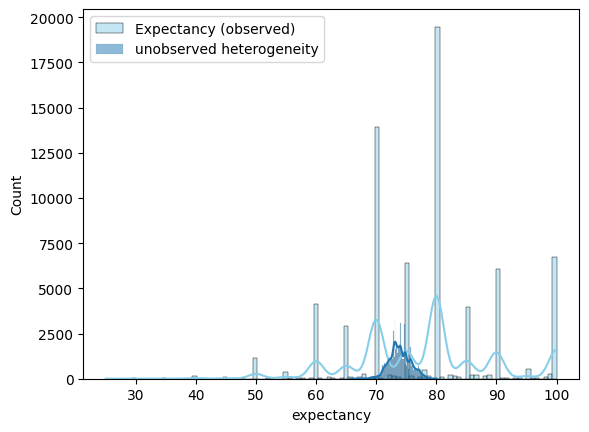

In [104]:

Xpred = X
Xpred["hombre"]=0
Xpred["edu_sin_nans"]=0
Xpred["kids"]=0
Xpred["children"]=0
Xpred["illness"]=0
Xpred["cronica"]=0
Xpred["nocronica"]=0
Xpred["mental"]=0
Xpred["year_4"]=0
Xpred["year_6"]=0
Xpred["year_9"]=0
Xpred["year_12"]=0

#Xpred["m_hombre"]=0
#Xpred["m_edu_sin_nans"]=0
#Xpred["m_kids"]=0
#Xpred["m_children"]=0
#Xpred["m_illness"]=0
#Xpred["m_cronica"]=0
#Xpred["m_nocronica"]=0
#Xpred["m_mental"]=0
#Xpred = sm.add_constant(Xpred)

yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="Expectancy (observed)", kde=True) # aqui se modifico
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True) # aqui se modifico

plt.legend() 
plt.show()

Respuesta pregunta 7:

Con el modelo CRE, lo que hacemos es separar lo que sí podemos observar —como salud,cantidad de hijos, educación— de lo que no podemos ver directamente, pero que igual afecta la expectativa de vida.

En el gráfico, esa parte no observada aparece en azul oscuro y se concentra entre los 70 y 80 años. Eso significa que algunas factoes —por ejemplo, regiones o personas— tienen algo constante en el tiempo que las hace vivir más o menos, aunque tengan los mismos valores en las variables observadas, es decir a pesar de tener variables parecidas hay una variacion presente de igual manera en aquellas entidades, esto por factores que no se observan(variabilidad no observada).

Por ejemplo, dos personas pueden tener la misma salud mental y educación, pero una puede tener mejor calidad de vida o cultura de autocuidado, y eso influye en su expectativa de vida.

Entonces, en conclusión, sí hay heterogeneidad fija en el tiempo que afecta los resultados, y que debemos tenerla en cuenta porque explica parte importante de las diferencias en longevidad.

Algo curioso es que parece haber un factor psicologico, por asi llamarlo, en las personas a responder con numeros de una cierta naturaleza(multiplos), casi como si decir un numero como 71 fuese decir algo muy especifico, y usar los "numeros multiplos" fuese mas "general".

In [105]:
yhat

predictions
folio_n20    time             
124560204870 2       70.751462
             3       70.751462
             4       70.751462
             5       70.751462
124560205935 1       74.197741
...                        ...
128133653188 5       73.293551
128133692735 5       70.259651
128133702320 5       73.479276
128133728022 5       71.002550
128133731927 5       74.779349

[70255 rows x 1 columns]

# PREGUNTA 8

Despues de todo lo visto me agrada mas el modelo de efectos aleatorios correalacionados, pues este si bien tiene variaciones que se explican por varaibles no observadas, creo que captura en mejor medida la informacion disponible al no dejar tan de lado variables con menor variacion entre el mismo individuo al considerar el efecto de estas de manera general. Por lo que este equiibrio que ofrece el modelo sumado a la correccion de estas varianza no observada me parece un analisis de la data mas completa que los demas modelos.

respecto del efecto de las variables explicativas se puede inferir que el efecto en la educacion es marginal, y no es realmente por si solo determinante en la expectativa de vida, sino que hay mas factores involucrados, los cuales en ciertas combinaciones " potencian" un efecto mas grande en la expectativa de vida que tiene las personas, ademas se puede decir que variables puedan ver indirectamente con el estado emocional de la persona tienen mucho que ver, a la vez que el momento por el que este pasando esa persona. asi tambien la varibale de enfermedad mental fue solida en indicar como esta afecta negativamente a la auto percepcion de uno en sus años de vida totales.Con respecto al resto de variables, posiblemente hay factores que se estan ignorando pues no suelen ser muy robustas, o si lo son, su efecto no es tan considerable.

# PREGUNTA 9